# EasyVisa Project

## Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired your firm EasyVisa for data-driven solutions. You as a data scientist have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

#Import libraries and load dataset

In [ ]:
#Library to read and manipulate data
import pandas as pd
import numpy as np

#Library to visualise data
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#Library to split data
from sklearn.model_selection import train_test_split

#Library to build model
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV

#Library to evaluate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

import scipy.stats as stats

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

#Library to ignore warnings
import warnings
warnings.filterwarnings('ignore')


# Data Overview

- Observations
- Sanity checks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
EV=pd.read_csv('/content/drive/MyDrive/EasyVisa.csv')

#Make a copy of the dataset

In [ ]:
data=EV.copy()

# Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

###Investigate the data

In [ ]:
# Look at the first 5 rows
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
#Look at the last five rows
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [ ]:
data.sample(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
18626,EZYV18627,Asia,Bachelor's,N,N,1964,2007,South,58422.64,Year,Y,Certified
6834,EZYV6835,Asia,Bachelor's,Y,Y,2639,1987,West,25666.20,Year,Y,Certified
10889,EZYV10890,Asia,Bachelor's,N,N,2801,1996,Northeast,278409.92,Year,Y,Certified
13665,EZYV13666,Asia,High School,Y,N,1936,1950,West,10927.90,Year,Y,Denied
13591,EZYV13592,Europe,High School,Y,N,234,1954,West,32139.19,Year,Y,Denied


In [ ]:
#Shape of the data
data.shape


(25480, 12)

- There are 25480 rows and 12 columns

In [ ]:
#Evaluate datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


- Most of the data are objects
- Number of employees and year of establishment are integers
- Prevailing wage is a float

In [ ]:
# Assess the statistical values of numeric values
data.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


- The average number of employees are 5667.04 with the minimum of   -26 and a maximum of 602069.00. The minimum could contain outliers.
- The average year of eastablishment is 1979. These values will be changed to reflect the age of the establishments. Range from year 1800 to 2016.
- The average prevailing wage is 74455.81, ranging from 2.13 to 319210.27. The unit of the wage is included in another column. Values include Hourly, Weekly, Monthly, and Yearly.

In [ ]:
# Describe the categorical values statistics
data.describe(include='object').T

,count,unique,top,freq
case_id,25480,25480,EZYV01,1
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


- Case id contains uique values and the column can be dropped.
- There are 6 continents with Asia the most frequent occuring.
- There are 4 education options with bachelor's as most frequent.
- Job experience, and job training  is given as yes or no.
- There are 5 regions of employment, Northeast being the most frequent.
- Full time position is indicated as yes or no. Most have a full time position
- Case-status is indicated as certified and uncertified. 17018 out of 25480 is certified.


###Drop unique columns

In [ ]:
data.drop('case_id',axis=1,inplace=True)
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


###Determine age from year of establishment

In [ ]:
from datetime import datetime
current_year = datetime.now().year
data['age_of_estab'] = current_year - data['yr_of_estab']
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,age_of_estab
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,18
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,23
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,17
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,128
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,20


In [ ]:
#drop year of establishment
data.drop('yr_of_estab',axis=1,inplace=True)
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,age_of_estab
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,18
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,23
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,17
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,128
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,20


###Define functions to compose graphs

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

**Leading Questions**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

##Univariate analysis

###Distribution over continents

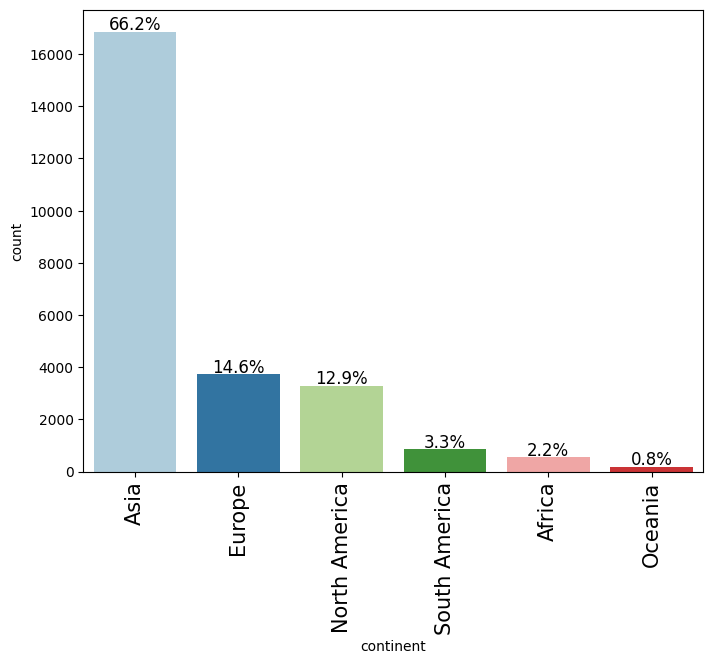

In [ ]:
labeled_barplot(data, 'continent', perc=True)

- Most of the employees are in Aisa, 66%
- Second is North America with 14.6%
- North Amedica follows in third place with 12.9%


###Education distribution among employees

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


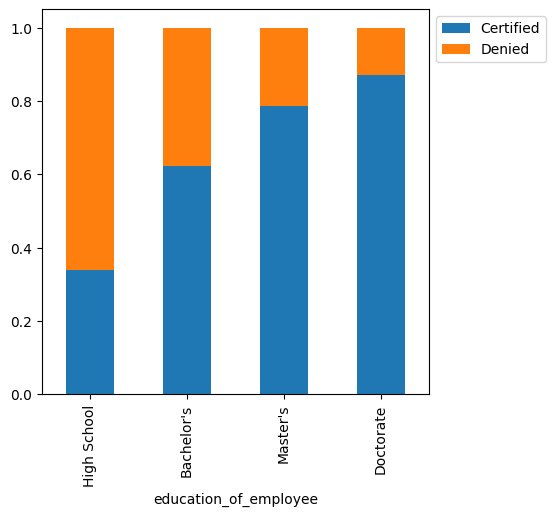

In [ ]:
stacked_barplot(data, 'education_of_employee', 'case_status')

- Graduated candidates have a higher percentage of certification

###Distribution of job experience

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


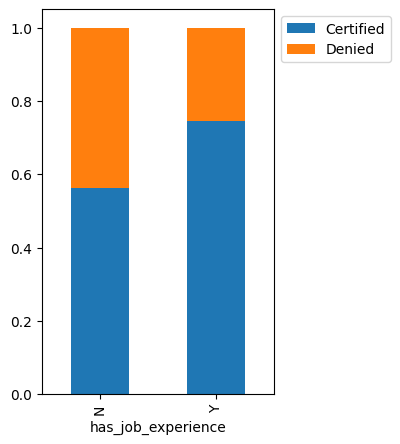

In [ ]:
stacked_barplot(data, 'has_job_experience', 'case_status')

In the "inexperienced" group:
- 58% were certified and 42% were denied (percentages are approximate values).
In the "experienced" group:
- 72% were certified and 28% were denied.
It is of value having job experience when applying for a Visa.


###Requires job training distribusion

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


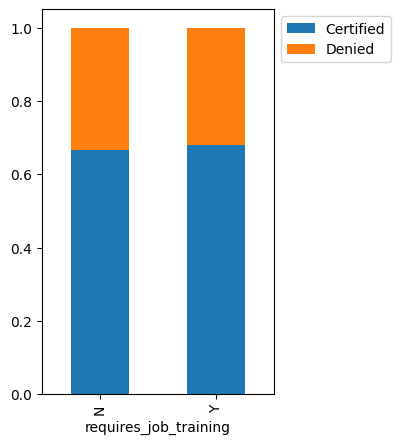

In [ ]:
stacked_barplot(data, 'requires_job_training', 'case_status')

-- Similar percentages of about 70% certified seen in the experienced and inexperienced group

###Employee numbers

- There is a very large number of outliers in this data, mostly to the right
- There are

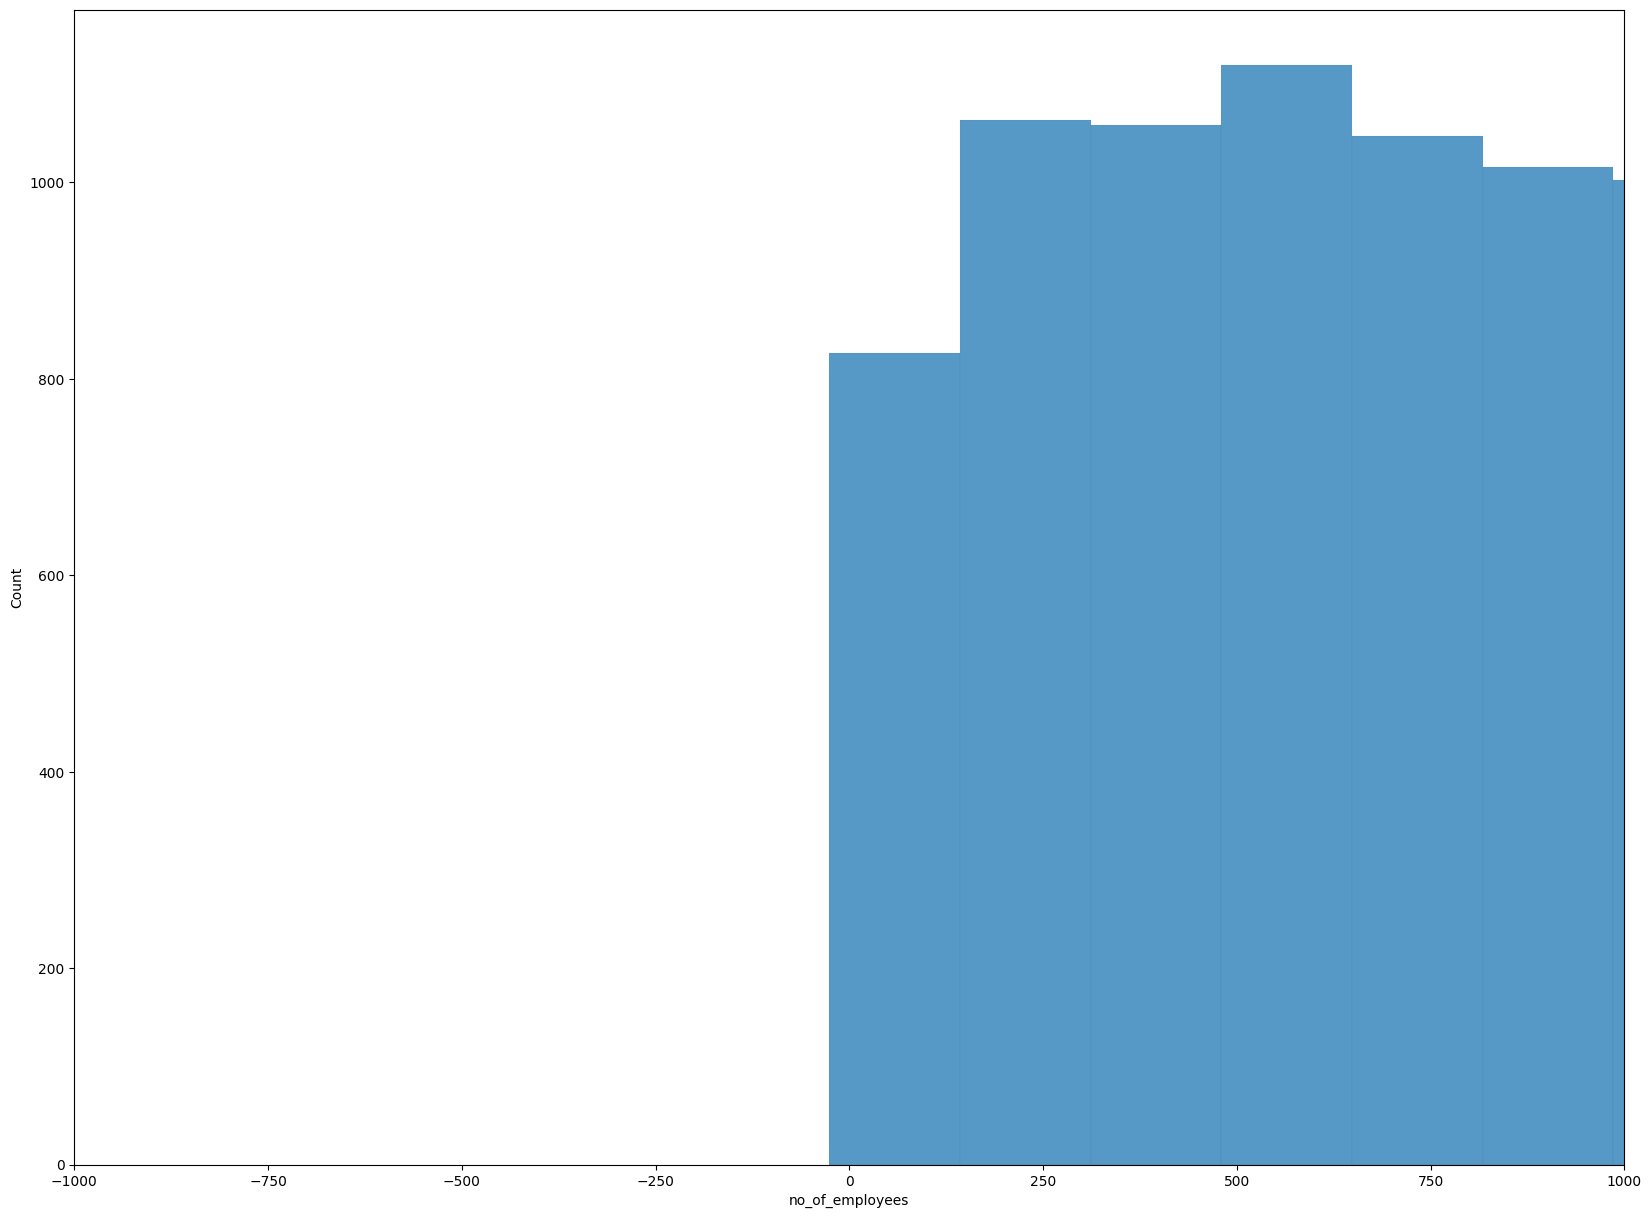

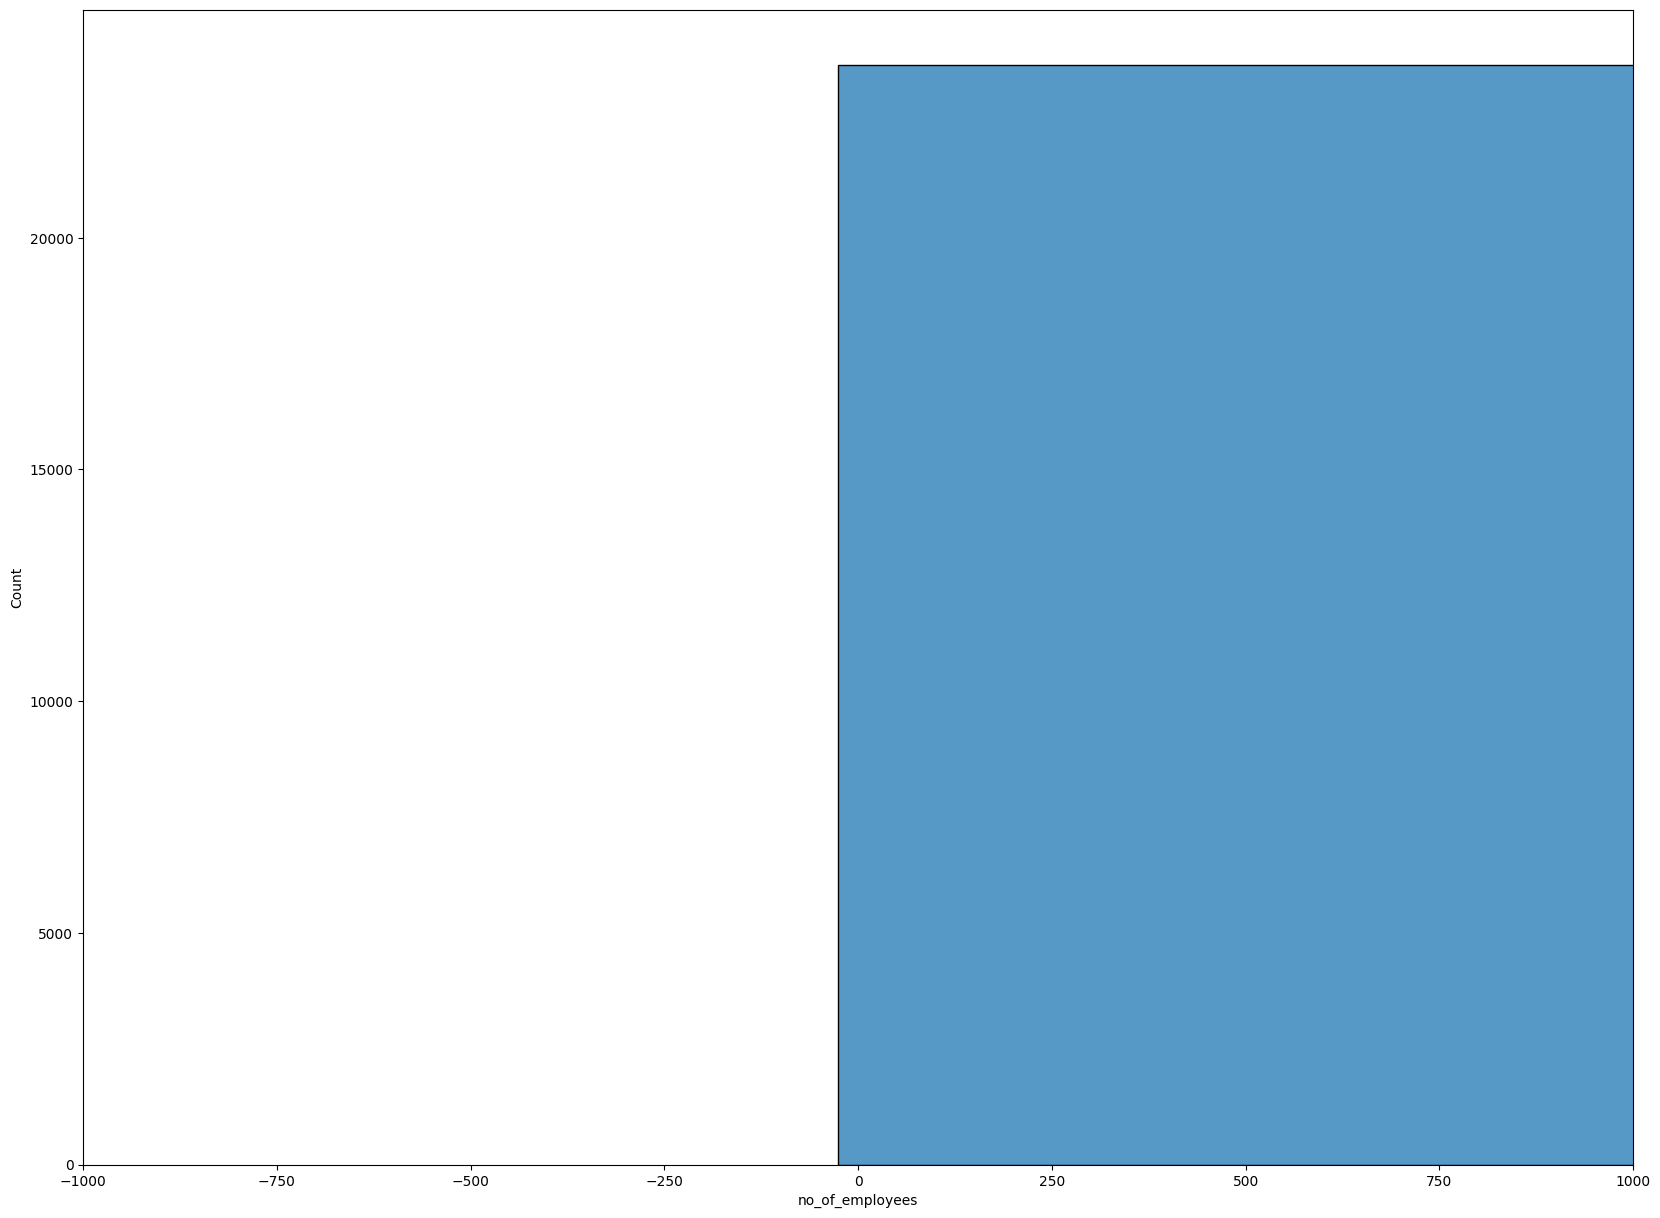

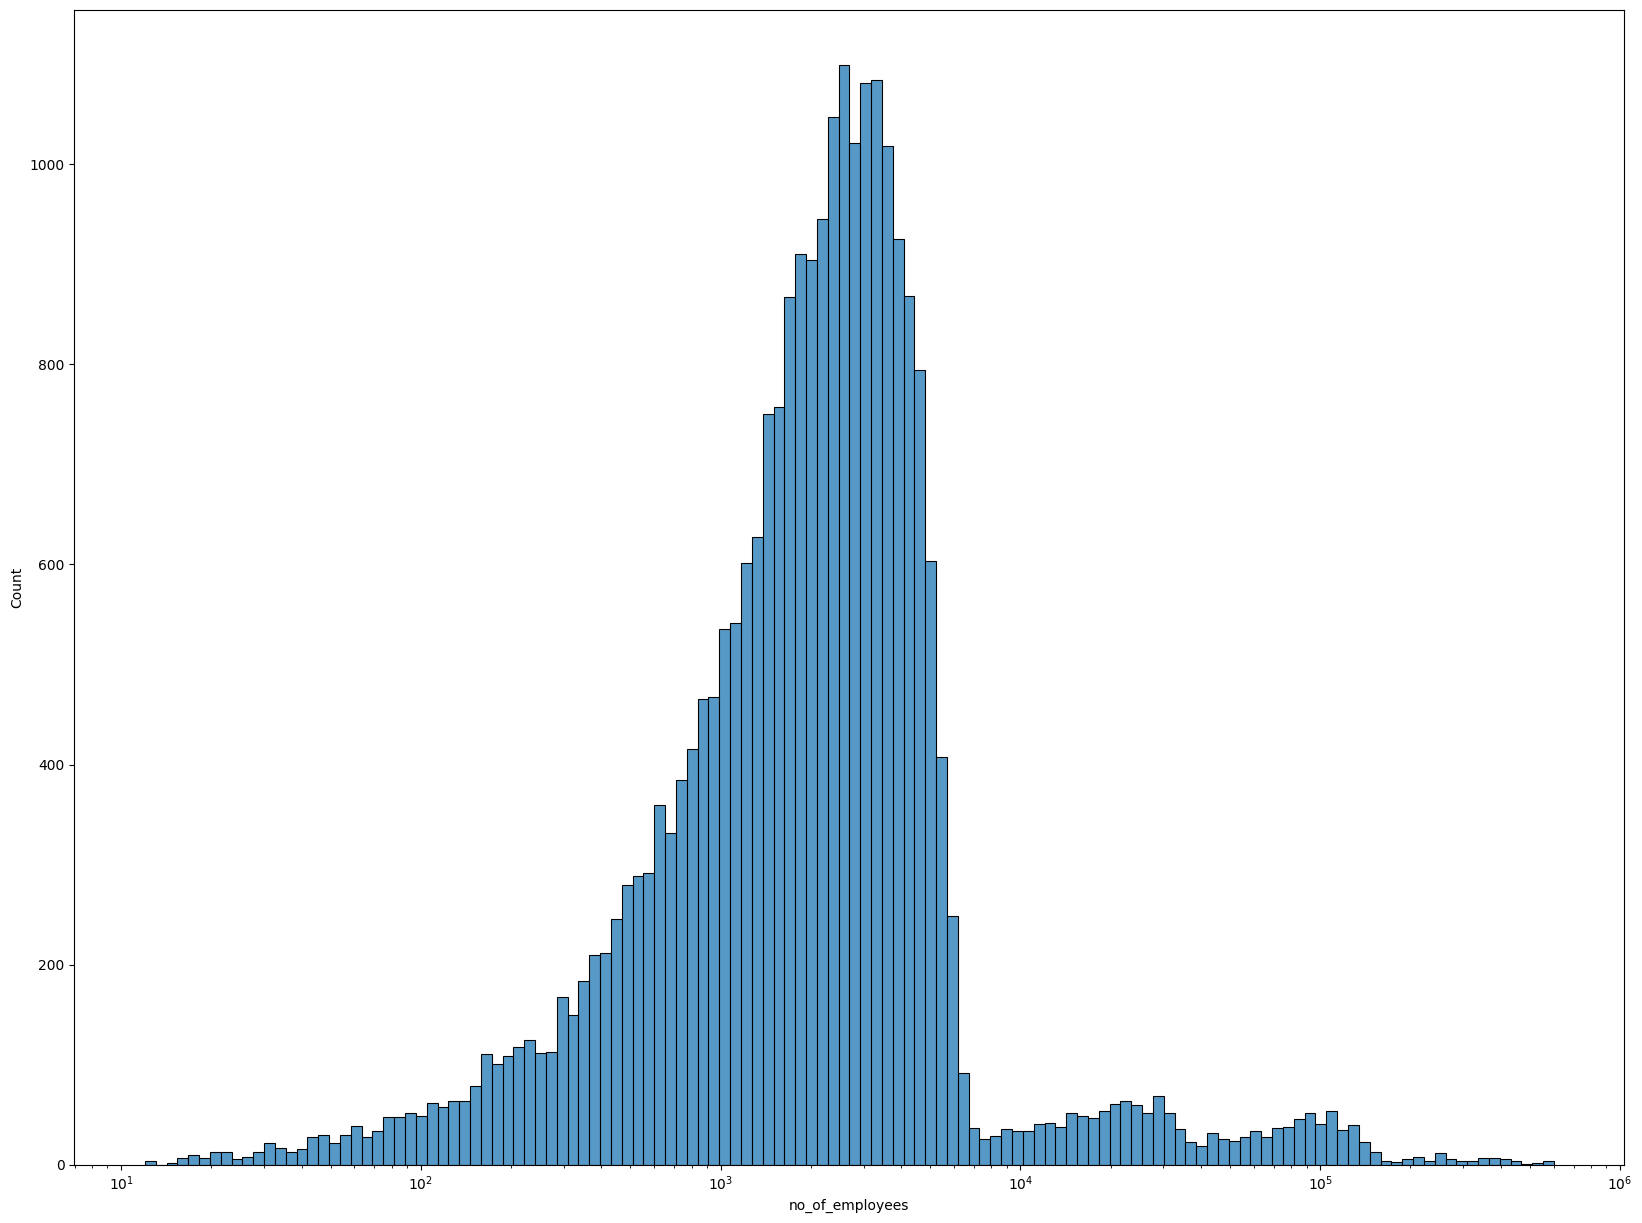

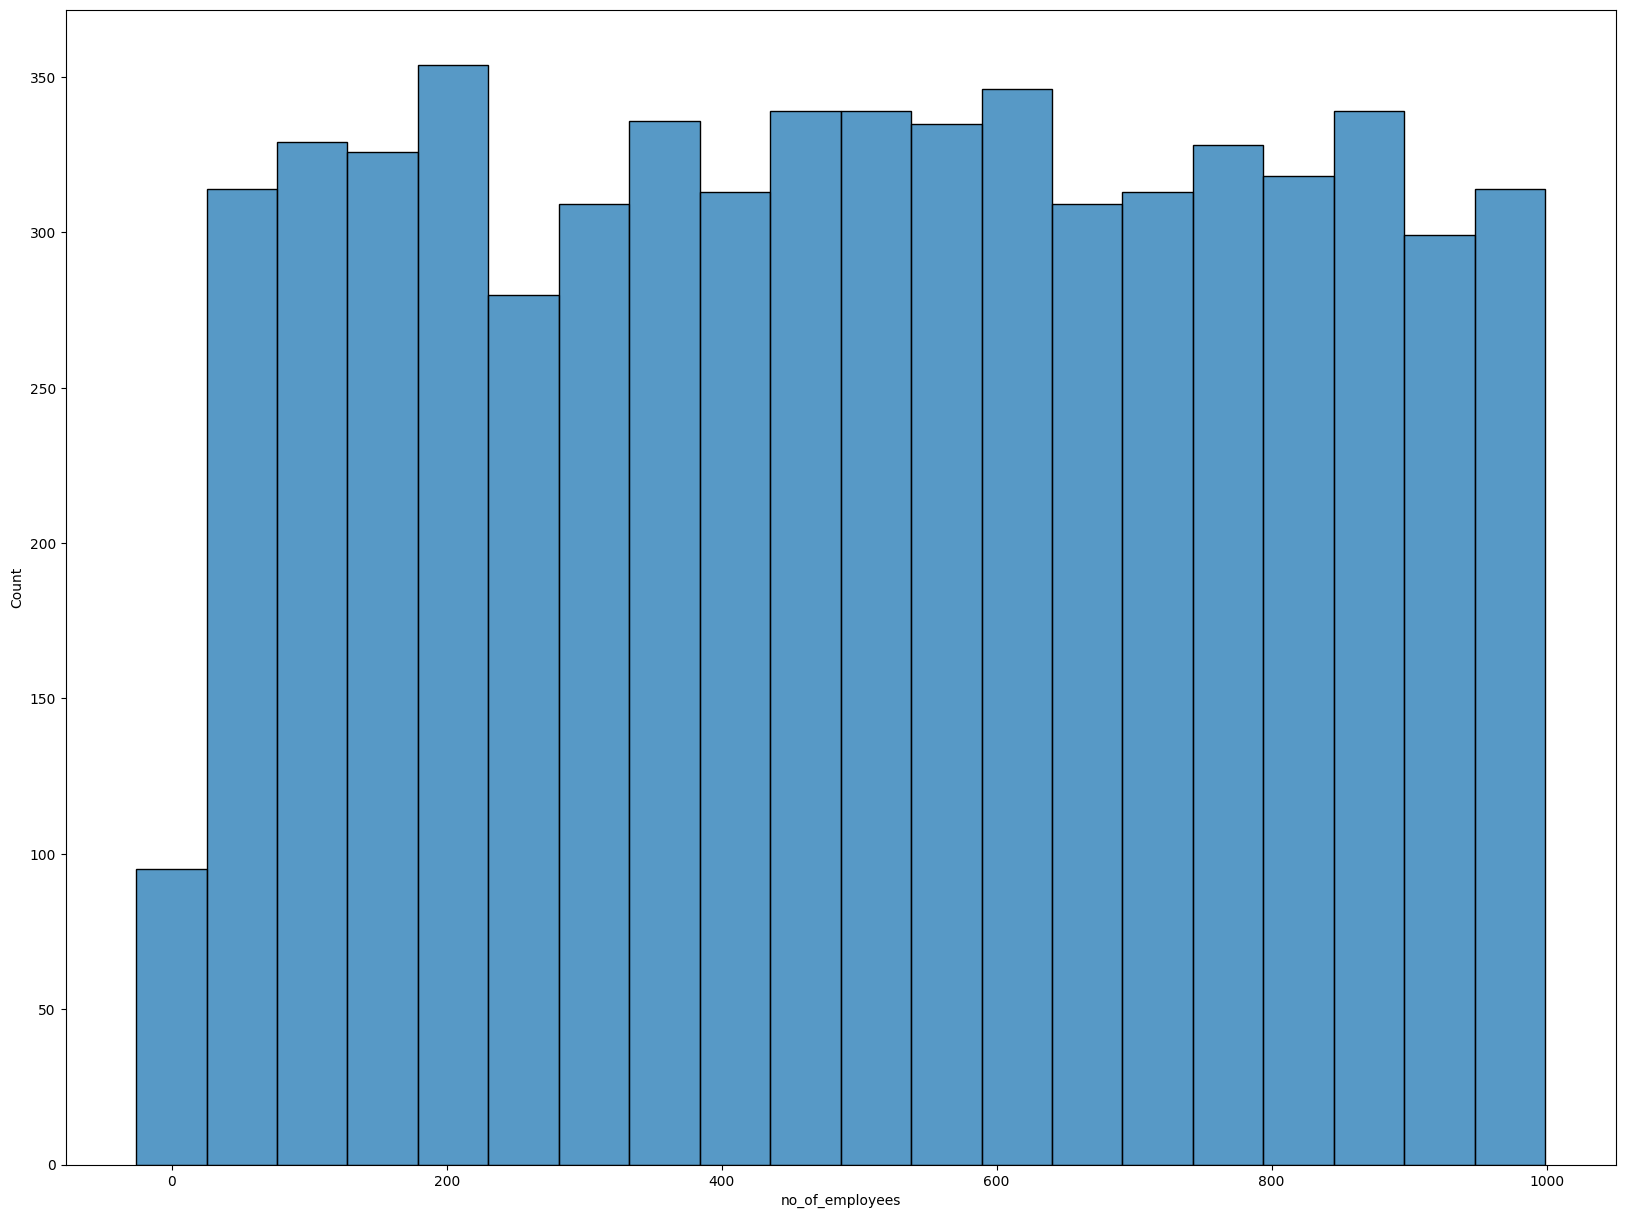

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame

# Adjust x-axis limits
plt.figure(figsize=(20, 15))  # Set the figure size
sns.histplot(data=data, x='no_of_employees')
plt.xlim(-1000, 1000)  # Example limits, change accordingly
plt.show()

# Adjust bin width
plt.figure(figsize=(20, 15))  # Set the figure size
sns.histplot(data=data, x='no_of_employees', bins=100)  # Adjust number of bins
plt.xlim(-1000, 1000)  # Example limits, change accordingly
plt.show()

# Logarithmic scale
plt.figure(figsize=(20, 15))  # Set the figure size
sns.histplot(data=data, x='no_of_employees', log_scale=True)
plt.show()

# Filtering data
filtered_data = data[data['no_of_employees'] < 1000]  # Example condition
plt.figure(figsize=(20, 15))  # Set the figure size
sns.histplot(data=filtered_data, x='no_of_employees')
plt.show()

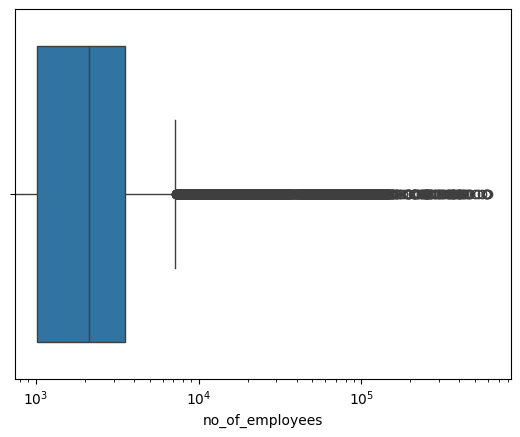

In [ ]:
sns. boxplot(data=data, x='no_of_employees')
plt.xscale('log')
plt.show()

- Number of employers are skewed to the left.
- There are a large number of outliers to the right.
The median is approximately 3200

###Age of the employer establishments

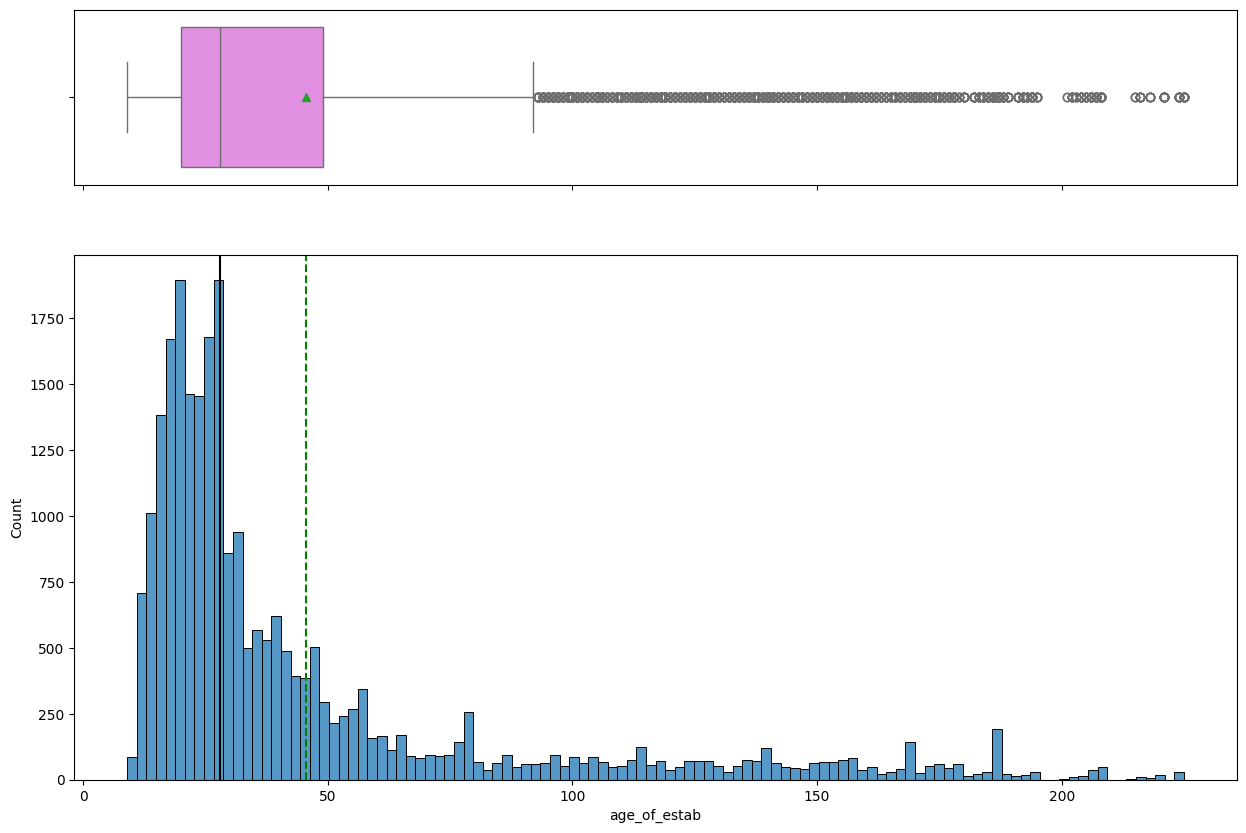

In [ ]:
histogram_boxplot(data, 'age_of_estab')
figsize=(15,10)

- Age is skewed to the right with a lot of outliers to the right.
- The Median is at about 25 years, and the mean is at about 48 years.

###Prevailing wage distribution

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


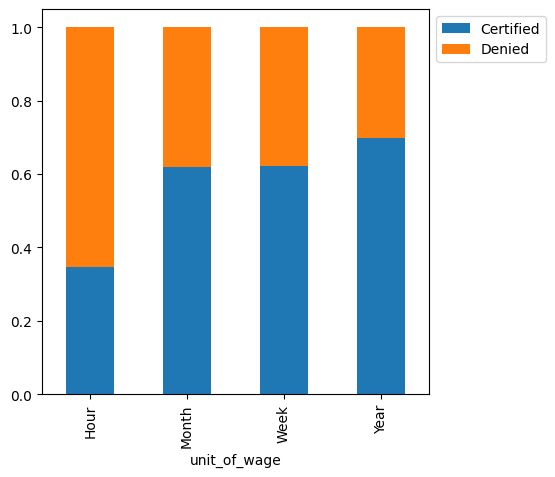

In [ ]:
stacked_barplot(data, 'unit_of_wage', 'case_status')

##Bivariate analysis

###Region vs Case status

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


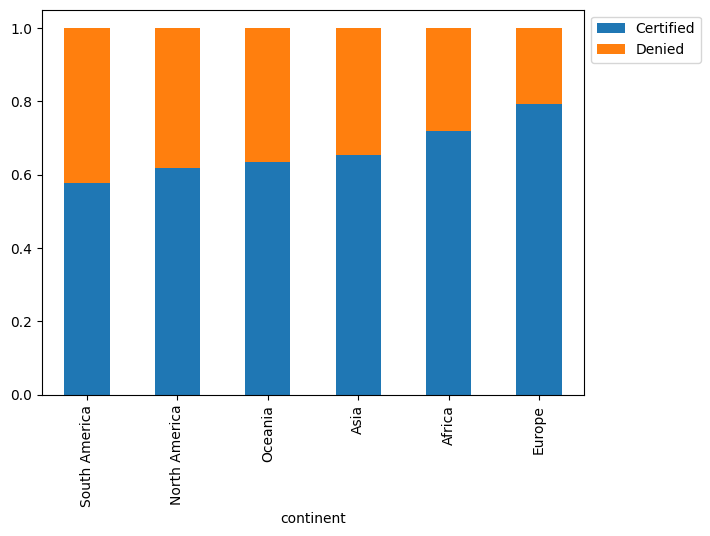

In [ ]:
stacked_barplot(data, 'continent', 'case_status')

- The visa was certified in Europe with about 80%
- There was a stepwise decrease in certification from Europe to Africa, to Asia, Oceania, North America and South America.

###Regions in the US

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


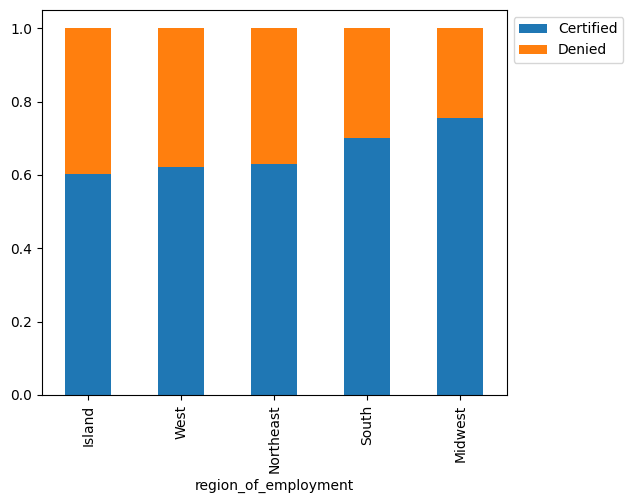

In [ ]:
stacked_barplot(data, 'region_of_employment', 'case_status')


- The top 3 regions of certification in America is in the  Midwest, South and Northeast America.

###Prevailing wage distribution by Case status

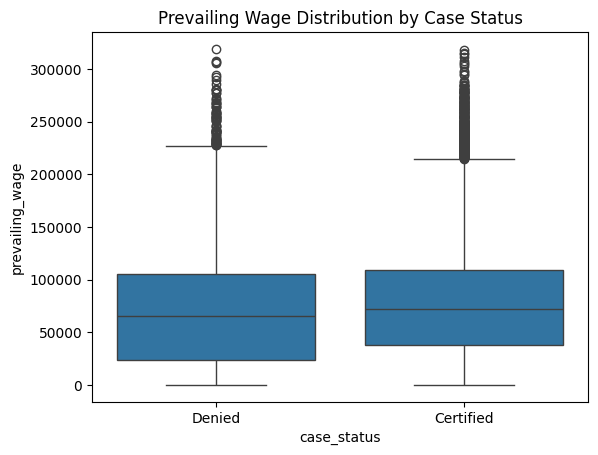

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='case_status', y='prevailing_wage', data=data)
plt.title('Prevailing Wage Distribution by Case Status')
plt.show()

- The distribution of prevailing wage is very similar in the certified and denied groups.
- Mean prevailing wage for both groups are about 65 000.
- There are outliers to the right in both groups.

###Education vs Case status

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


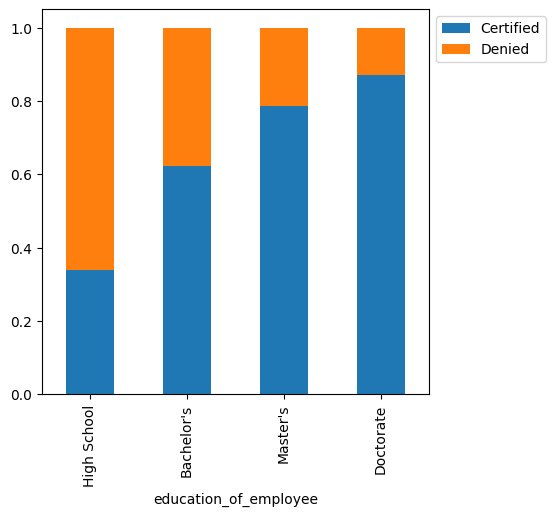

In [ ]:

stacked_barplot(data, 'education_of_employee', 'case_status')

- As the education degree increases, the certification status increases. They seem to be correlated.
- The certification of  Doctorate employees are 85%, of Master's degrees are about 80% and of Bachelor's are about 60%.
- The lowest certification percentage is in High School graduates at about 35%.



```
# This is formatted as code
```

###Pay intervals vs Case status

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


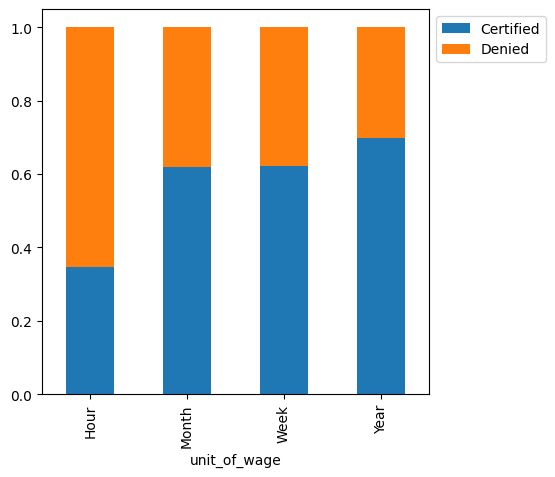

In [ ]:
stacked_barplot(data, 'unit_of_wage', 'case_status')

- Yearly is the unit that is mostly used and approximately 70% of these are certified.
- Hourly is the rate that is used less frequently, with 35% of the group certified.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

###Assess for missing data and look for duplicates

In [ ]:
#Change objects to category
data[data.select_dtypes(include=['object']).columns] = data.select_dtypes(include=['object']).apply(lambda x: x.astype('category'))

In [ ]:
data.sample(10)


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,age_of_estab
7396,North America,High School,Y,N,2157,South,13274.33,Year,Y,Certified,12
4624,Asia,Bachelor's,Y,Y,1840,South,34520.49,Year,Y,Certified,26
16504,Asia,Master's,Y,N,1320,Midwest,74229.96,Year,Y,Certified,76
20790,Europe,Doctorate,Y,N,3110,West,82089.00,Year,Y,Certified,205
7268,Europe,Doctorate,Y,N,1702,Midwest,53770.00,Year,Y,Certified,25
25027,North America,Doctorate,Y,N,3610,Northeast,90870.69,Year,Y,Certified,19
17154,Europe,Bachelor's,N,N,16646,Northeast,78754.27,Year,Y,Certified,22
20290,Asia,Master's,N,N,252500,Midwest,50696.79,Year,Y,Certified,21
7802,Asia,Bachelor's,N,N,1117,West,114776.49,Year,Y,Certified,17
18371,Asia,Bachelor's,Y,N,2229,Northeast,5616.11,Year,Y,Certified,187


In [ ]:
data.isnull().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0
case_status,0


- There are no missing values

In [ ]:
duplicates = data.duplicated()
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 0


###Detect outliers and treatment

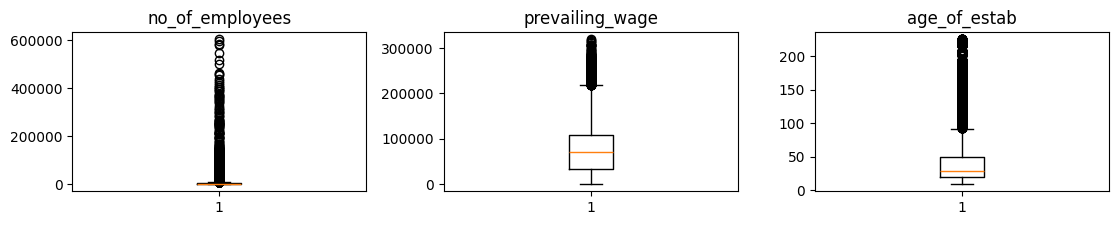

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(6, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

- There are a lot of outliers in the numerical columns.
- The outliers will not be treated.

In [ ]:
#Treat outliers in numerical data, by clipping whiskers
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
#Clip whiskers
for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])


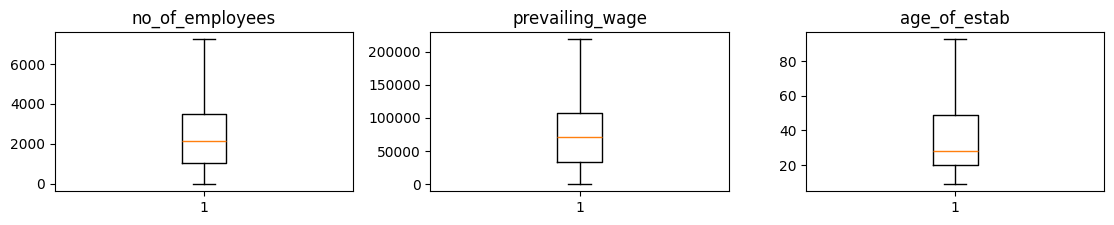

In [ ]:
# review outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(6, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

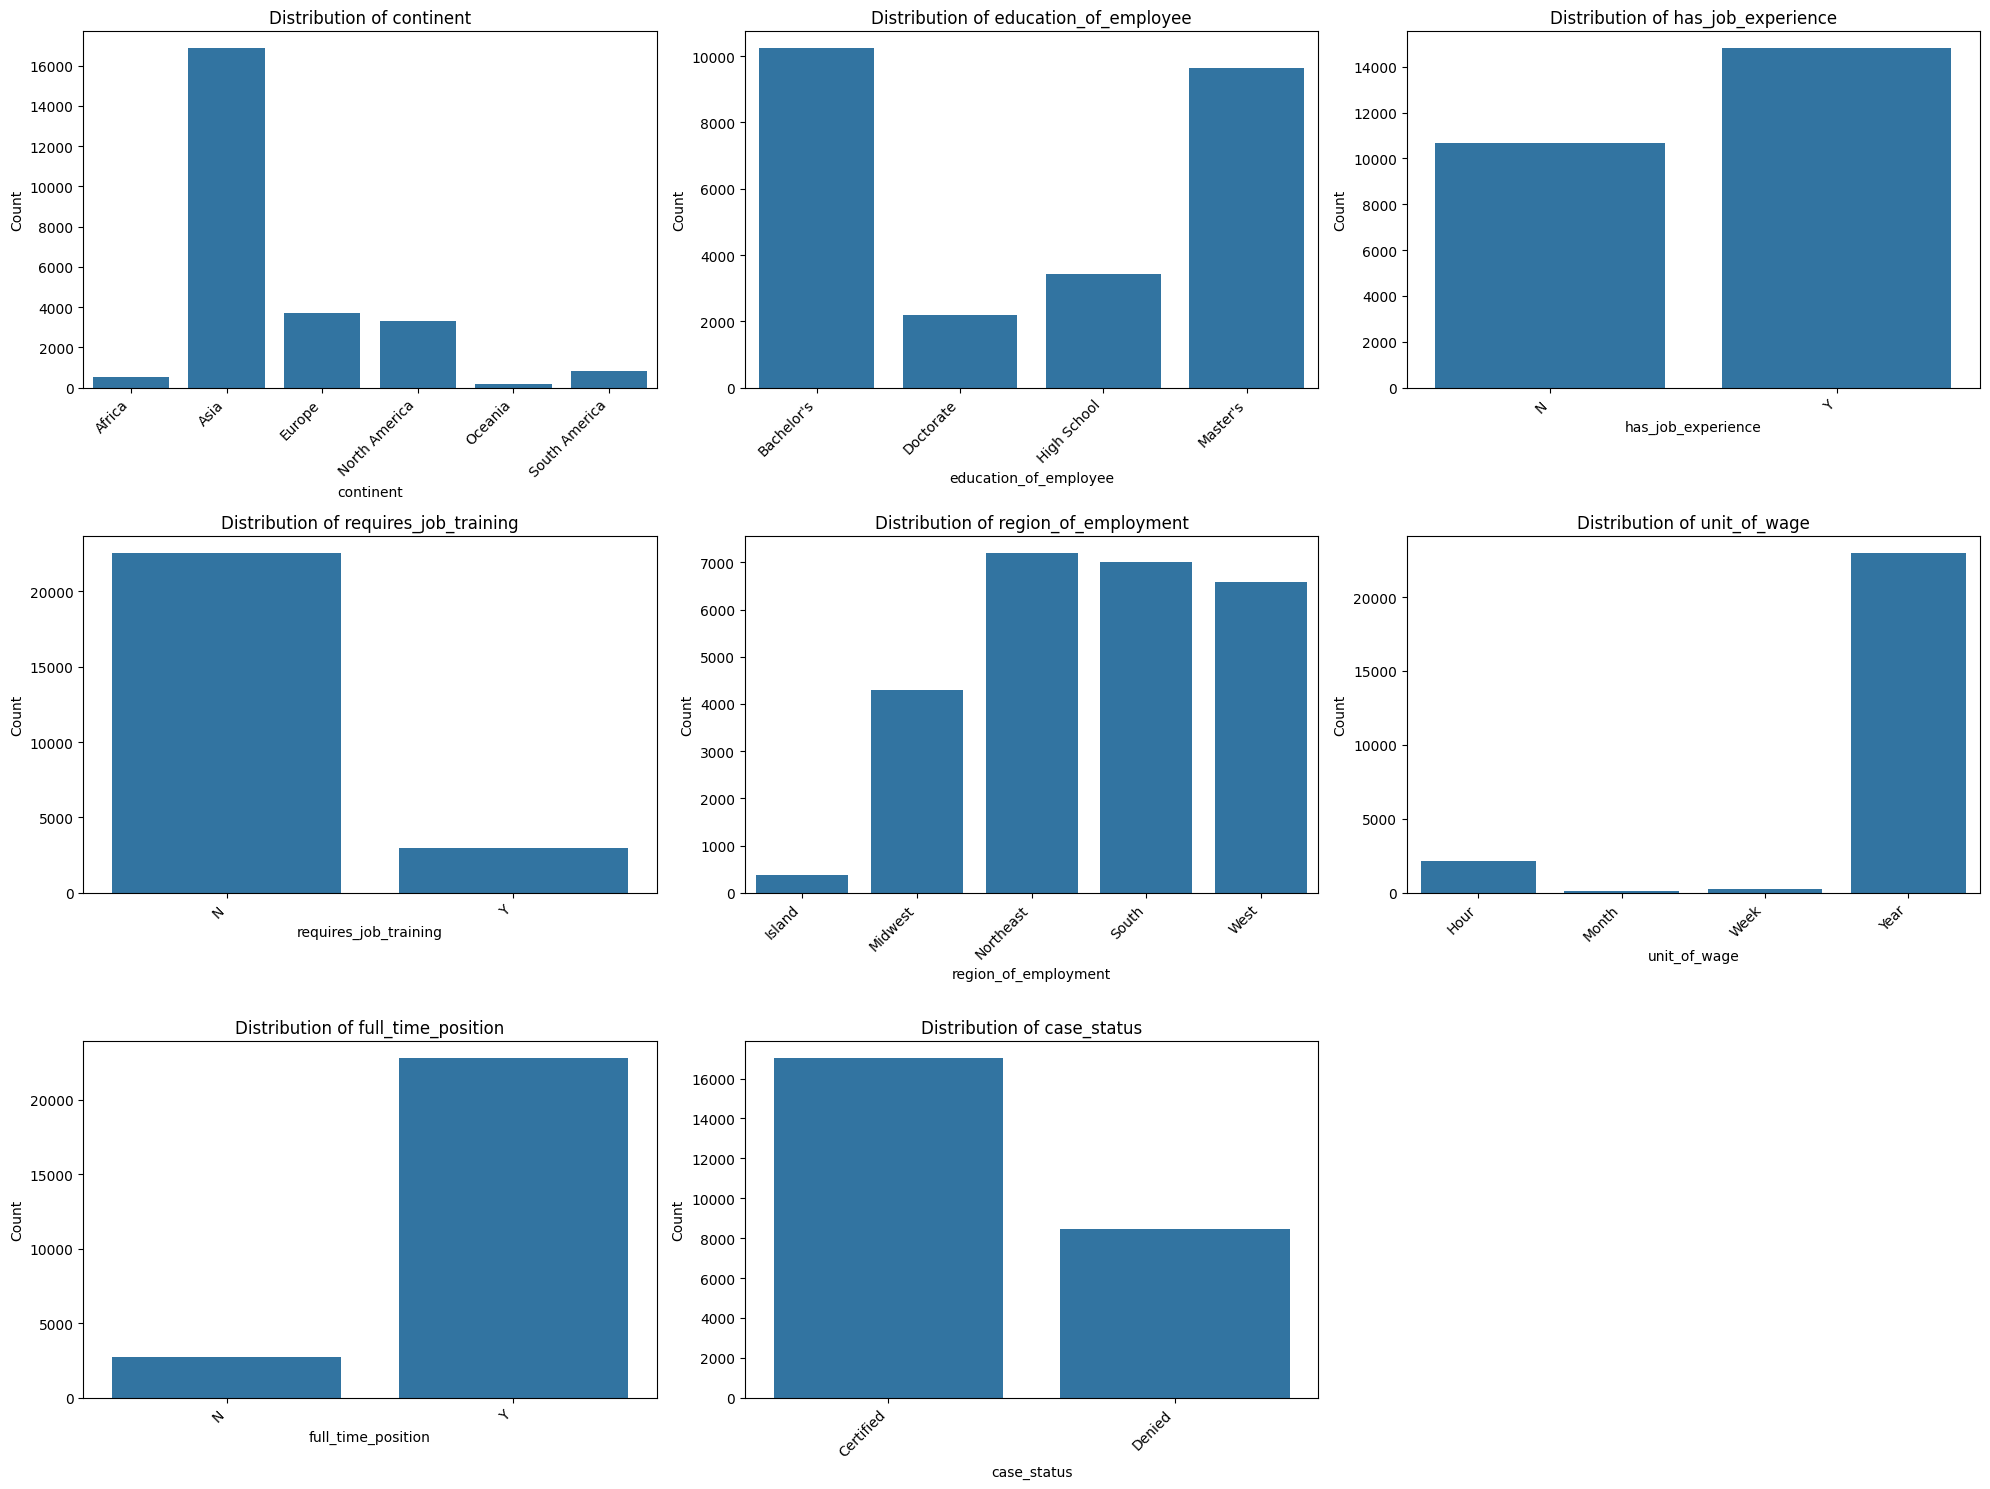


Distribution of continent:
               Count  Percentage
continent                       
Asia           16861   66.173469
Europe          3732   14.646782
North America   3292   12.919937
South America    852    3.343799
Africa           551    2.162480
Oceania          192    0.753532

Distribution of education_of_employee:
                       Count  Percentage
education_of_employee                   
Bachelor's             10234   40.164835
Master's                9634   37.810047
High School             3420   13.422292
Doctorate               2192    8.602826

Distribution of has_job_experience:
                    Count  Percentage
has_job_experience                   
Y                   14802   58.092622
N                   10678   41.907378

Distribution of requires_job_training:
                       Count  Percentage
requires_job_training                   
N                      22525   88.402669
Y                       2955   11.597331

Distribution of region_of_em

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get categorical columns
categorical_columns = [
    'continent', 'education_of_employee', 'has_job_experience',
    'requires_job_training', 'region_of_employment', 'unit_of_wage',
    'full_time_position', 'case_status'
]

# Set up the figure size
plt.figure(figsize=(20, 15))

# Create bar plots for each categorical variable
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    value_counts = data[col].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print value counts and percentage for each category
for col in categorical_columns:
    print(f"\nDistribution of {col}:")
    value_counts = data[col].value_counts()
    percentage = data[col].value_counts(normalize=True) * 100
    distribution_df = pd.DataFrame({
        'Count': value_counts,
        'Percentage': percentage
    })
    print(distribution_df)


Rare categories in continent (< 1.0%):
Oceania: 0.75%

Rare categories in education_of_employee (< 1.0%):

Rare categories in has_job_experience (< 1.0%):

Rare categories in requires_job_training (< 1.0%):

Rare categories in region_of_employment (< 1.0%):

Rare categories in unit_of_wage (< 1.0%):
Month: 0.35%

Rare categories in full_time_position (< 1.0%):

Rare categories in case_status (< 1.0%):


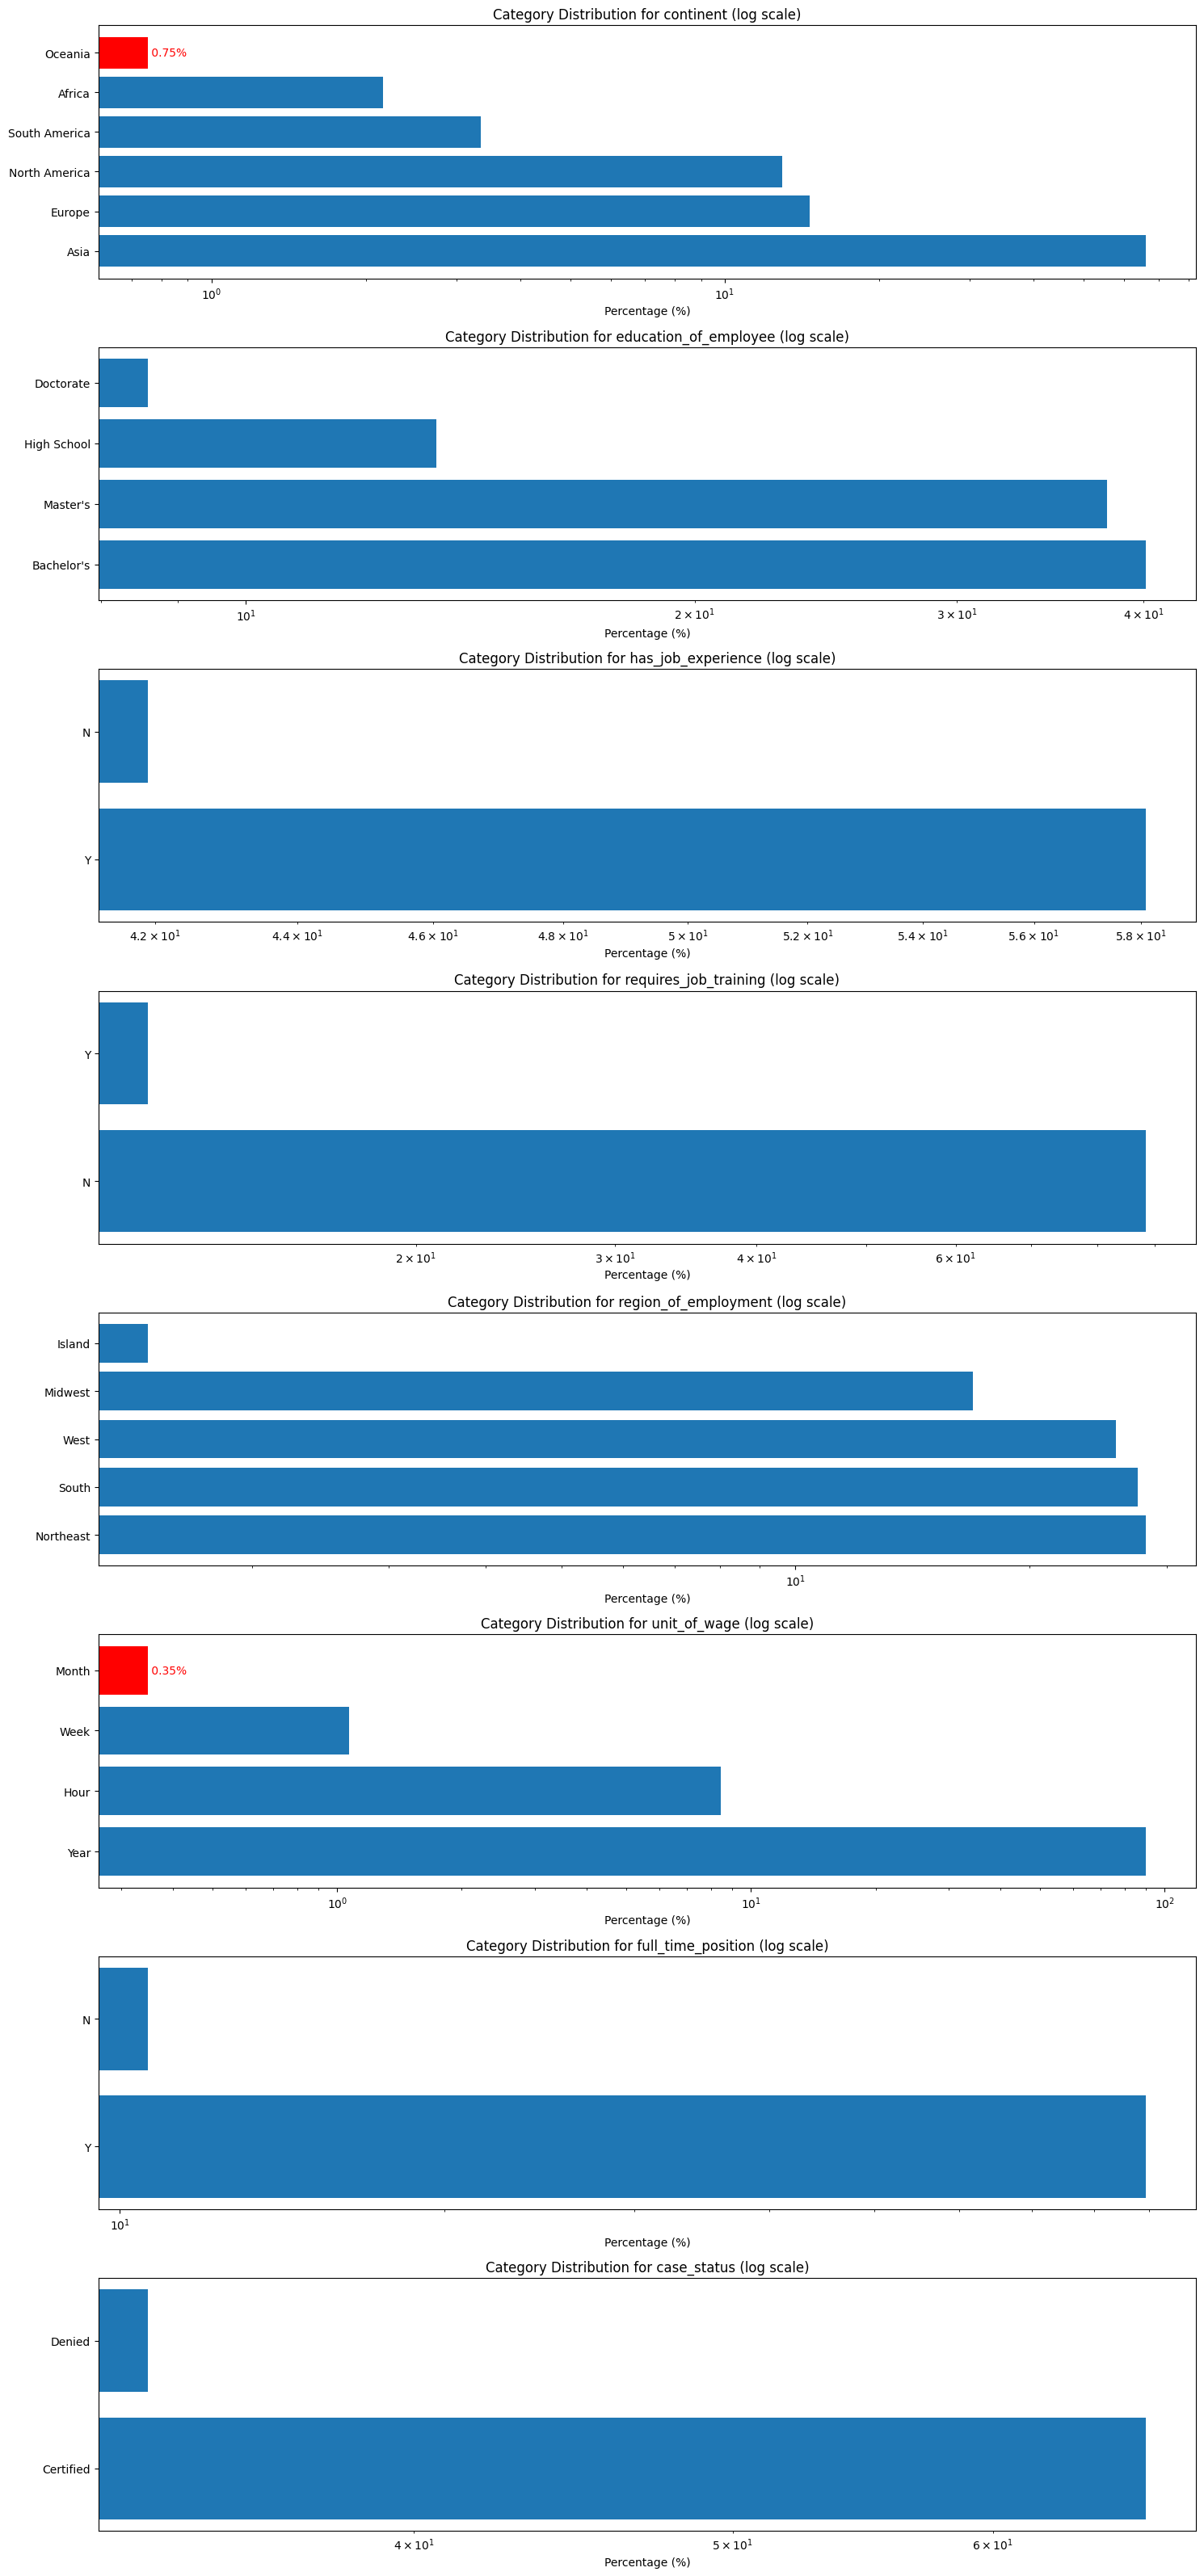

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_categorical_outliers(data, categorical_columns, rare_threshold=0.01):
    plt.figure(figsize=(15, len(categorical_columns)*4))

    for idx, col in enumerate(categorical_columns, 1):
        # Calculate value frequencies and percentages
        value_counts = data[col].value_counts()
        value_percentages = (value_counts / len(data)) * 100

        # Identify rare categories (less than threshold%)
        rare_categories = value_percentages[value_percentages < rare_threshold * 100]

        # Create subplot
        plt.subplot(len(categorical_columns), 1, idx)

        # Plot frequencies on log scale to highlight rare categories
        plt.barh(range(len(value_percentages)), value_percentages)
        plt.yticks(range(len(value_percentages)), value_counts.index)
        plt.xlabel('Percentage (%)')
        plt.title(f'Category Distribution for {col} (log scale)')
        plt.xscale('log')  # Use log scale to better visualize rare categories

        # Highlight rare categories in red
        if len(rare_categories) > 0:
            rare_indices = [list(value_percentages.index).index(cat) for cat in rare_categories.index]
            plt.barh(rare_indices, rare_categories, color='red')

        # Add text annotations for rare categories
        for i, v in enumerate(value_percentages):
            if v < rare_threshold * 100:
                plt.text(v, i, f' {v:.2f}%', va='center', color='red')

        print(f"\nRare categories in {col} (< {rare_threshold*100}%):")
        for cat, pct in rare_categories.items():
            print(f"{cat}: {pct:.2f}%")

    plt.tight_layout()
    plt.show()

# Example usage:
categorical_columns = [
    'continent', 'education_of_employee', 'has_job_experience',
    'requires_job_training', 'region_of_employment', 'unit_of_wage',
    'full_time_position', 'case_status'
]

analyze_categorical_outliers(data, categorical_columns, rare_threshold=0.01)

###Prepare data for modelling

In [ ]:
#Create dummies to prepare for modelling
data=pd.get_dummies(data,drop_first=True)
data.head()

,no_of_employees,prevailing_wage,age_of_estab,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,...,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y,case_status_Denied
0,7227.0,592.2029,18.0,True,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,True,True
1,2412.0,83425.6500,23.0,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,False
2,7227.0,122996.8600,17.0,True,False,False,False,False,False,False,...,True,False,False,False,True,False,False,True,True,True
3,98.0,83434.0300,92.5,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,True,True,True
4,1082.0,149907.3900,20.0,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,True,False


In [ ]:
#Change datatype to float
data = data.astype(float)

In [ ]:
data.head()

,no_of_employees,prevailing_wage,age_of_estab,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,...,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y,case_status_Denied
0,7227.0,592.2029,18.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1,2412.0,83425.6500,23.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,7227.0,122996.8600,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
3,98.0,83434.0300,92.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
4,1082.0,149907.3900,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


##Heatmap of numerical values

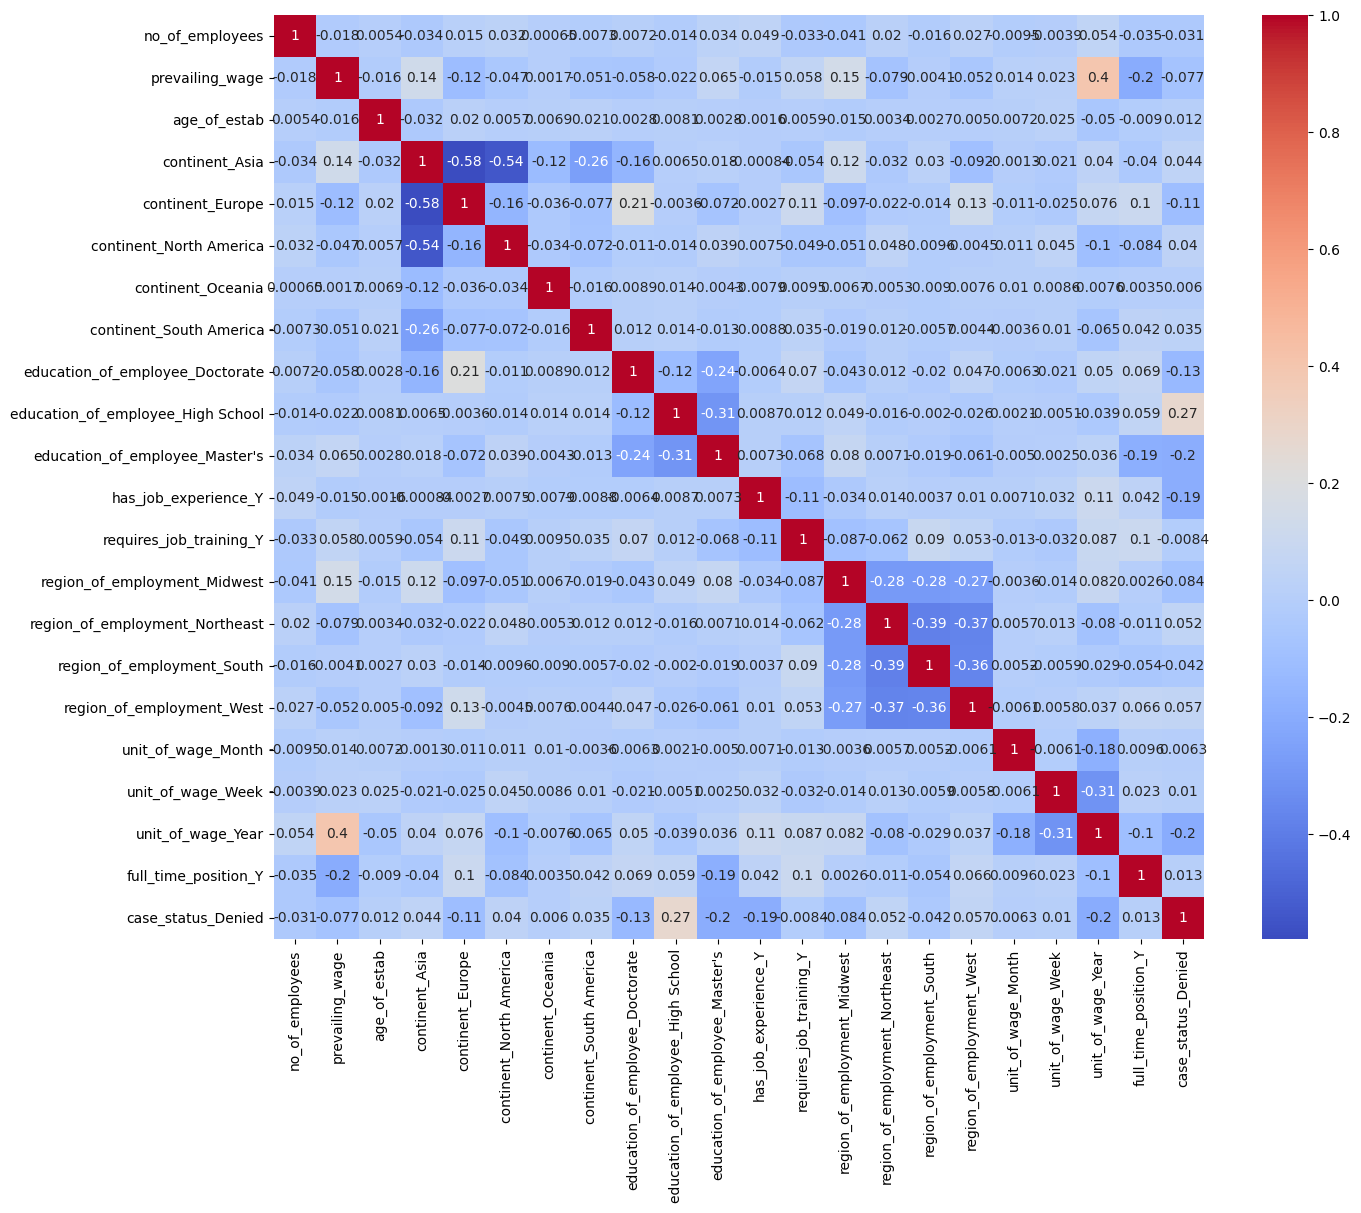

In [ ]:
#Create correlation matrix of only the numerical columns
numeric_columns = data.select_dtypes(include=np.number).columns.tolist() # Get numerical columns
corr_matrix = data[numeric_columns].corr() # Calculate the correlation matrix

#Create heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Correlation with case status:
- The unit wage hourly is negatively correlated with denied case status.
- Education level of high school graduate is positively correlated with denied case status. Education level of Doctorate degree is negatively correlated with denied case status.
- The above are weakly correlated.
- The other factors are not correlated with case status.

Other correlations:
- Yearly unit wage is positively correlated with prevailing wage.

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
data.head()

,no_of_employees,prevailing_wage,age_of_estab,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,education_of_employee_Doctorate,education_of_employee_High School,...,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y,case_status_Denied
0,7227.0,592.2029,18.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1,2412.0,83425.6500,23.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,7227.0,122996.8600,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
3,98.0,83434.0300,92.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
4,1082.0,149907.3900,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


## Building bagging and boosting models

In [ ]:
X = data.drop("case_status_Denied" , axis=1)
y = data.pop("case_status_Denied")

###Split the data into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Assuming 'X' is your features and 'y' is your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


###Create functions to calculate different metrics- Accuracy, Recall and Precision and plot the confusion matrix


In [ ]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
from sklearn import metrics
##  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model,flag=True, pos_label=1 ):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    #Predicting on train and tests
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    #Accuracy of the model
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)

    #Recall of the model
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)

    #Precision of the model
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)

    #f1-score of the model
    train_f1 = metrics.f1_score(y_train,pred_train)
    test_f1 = metrics.f1_score(y_test,pred_test)



    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision,train_f1,test_f1))

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train, pos_label=1))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test, pos_label=1))
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train,pos_label=1))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test,pos_label=1))
        print("F1-score on training set : ",metrics.f1_score(y_train,pred_train))
        print("F1-score on test set : ",metrics.f1_score(y_test,pred_test))

    return score_list # returning the list with train and test scores



#Bagging - Model Building and Hyperparameter Tuning

### Decision Tree


In [ ]:
#Use decision tree classifier function
from sklearn.tree import DecisionTreeClassifier

decision_tree_estimator = DecisionTreeClassifier(random_state=1)

# Only print the parameters
print("Decision Tree Classifier Parameters:")
print(decision_tree_estimator.get_params())
# Add weight balanced
decision_tree_estimator.class_weight='balanced'
#add stratify
decision_tree_estimator.stratify=True
decision_tree_estimator.fit(X_train, y_train)

Decision Tree Classifier Parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 1, 'splitter': 'best'}


DecisionTreeClassifier(class_weight='balanced', random_state=1)

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
#View the metrics
decision_tree_estimator_score=get_metrics_score(decision_tree_estimator)

Accuracy on training set :  1.0
Accuracy on test set :  0.6581632653061225
Recall on training set :  1.0
Recall on test set :  0.4710401891252955
Precision on training set :  1.0
Precision on test set :  0.48479318734793186
F1-score on training set :  1.0
F1-score on test set :  0.47781774580335734


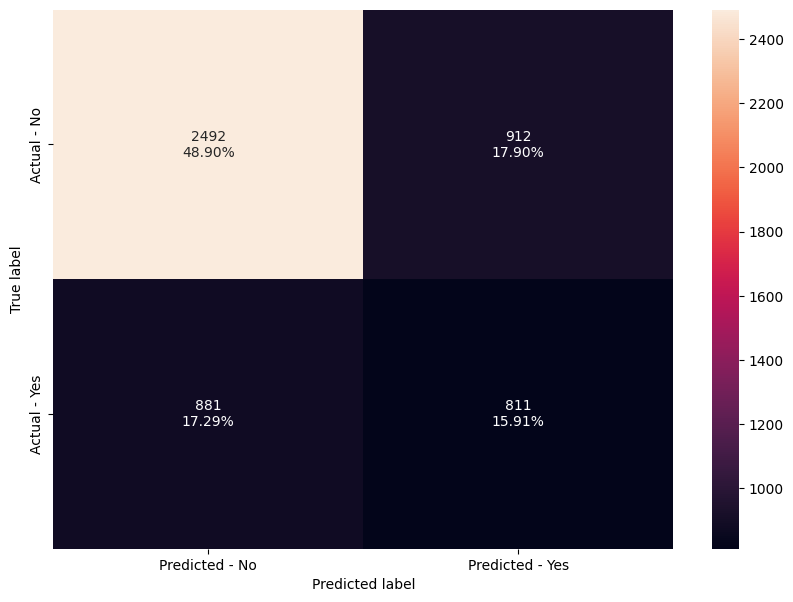

In [ ]:
#View the confusionmatrix
make_confusion_matrix(decision_tree_estimator,y_test)

- The model is overfitting.
- Poor recall of 46% and poor precision of 46%.
- F1 score: low. The model struggles to balance recall and precesion. Significant improvement is required.

##Descision tree with hyperparameters

In [ ]:
# Choose the type of classifier.
decision_tree_estimator_tuned = DecisionTreeClassifier(random_state=1)

# Only print the parameters
print("Decision Tree Classifier Parameters:")
print(decision_tree_estimator_tuned.get_params())

# Grid of parameters to choose from
## add from article
parameters = {'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(decision_tree_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
decision_tree_estimator_tuned.fit(X_train, y_train)

Decision Tree Classifier Parameters:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 1, 'splitter': 'best'}


DecisionTreeClassifier(random_state=1)

In [ ]:
#Metrics to assess tuned decision tree
decision_tree_estimator_tuned_score=get_metrics_score(decision_tree_estimator_tuned)

Accuracy on training set :  1.0
Accuracy on test set :  0.6481554160125589
Recall on training set :  1.0
Recall on test set :  0.4793144208037825
Precision on training set :  1.0
Precision on test set :  0.4706906558328497
F1-score on training set :  1.0
F1-score on test set :  0.4749633967789165


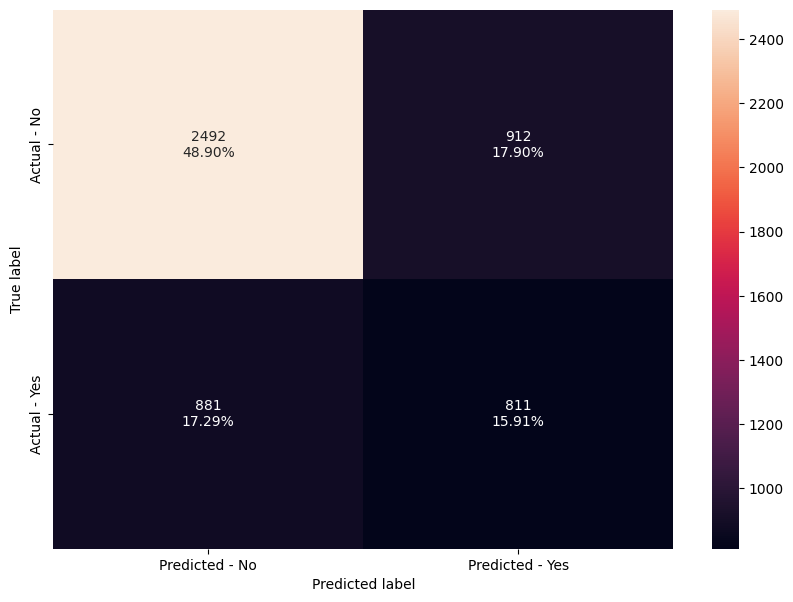

In [ ]:
#Confusion matrix
make_confusion_matrix(decision_tree_estimator_tuned,y_test)

- The model is overfitting on training data.
- Recall and precision is poor.
- Hyperparameters do not improve F1 score.

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print(pd.DataFrame(decision_tree_estimator_tuned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                        Imp
prevailing_wage                    0.304711
no_of_employees                    0.251543
age_of_estab                       0.153777
education_of_employee_High School  0.078134
has_job_experience_Y               0.036326
education_of_employee_Master's     0.018711
continent_Europe                   0.017764
full_time_position_Y               0.016922
region_of_employment_South         0.015993
region_of_employment_Midwest       0.015820
requires_job_training_Y            0.015370
education_of_employee_Doctorate    0.013758
region_of_employment_Northeast     0.013119
continent_Asia                     0.011527
region_of_employment_West          0.011301
continent_North America            0.008068
continent_South America            0.006435
unit_of_wage_Year                  0.005017
continent_Oceania                  0.002148
unit_of_wage_Week                  0.002097
unit_of_wage_Month                 0.001460


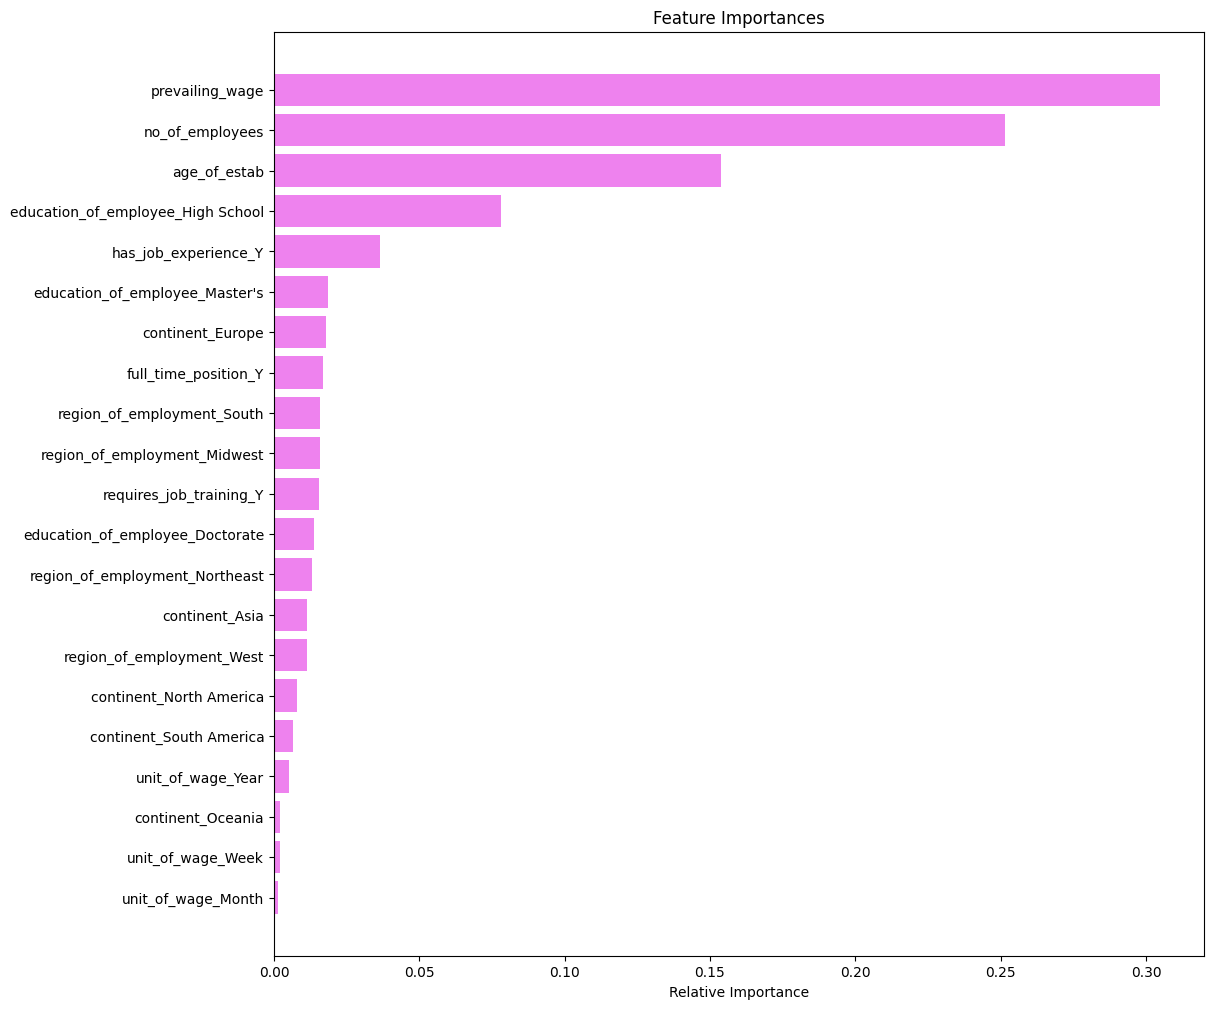

In [ ]:
feature_names = X_train.columns
importances = decision_tree_estimator_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

- Prevailing wage, number of employees and age of establishment are the variables of most importance

##Bagging classifier

In [ ]:
#Base estimator for Bagging Classifier is a decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

In [ ]:
bagging_estimator=BaggingClassifier(random_state=1)
bagging_estimator.fit(X_train,y_train)

# Only print the parameters
print("Bagging Classifier Parameters:")
print(bagging_estimator.get_params())



Bagging Classifier Parameters:
{'bootstrap': True, 'bootstrap_features': False, 'estimator': None, 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': 1, 'verbose': 0, 'warm_start': False}


In [ ]:
#Use above function to get accuracy, recall and precesion
bagging_estimator_score=get_metrics_score(bagging_estimator)

Accuracy on training set :  0.9787578492935636
Accuracy on test set :  0.7031004709576139
Recall on training set :  0.9413589364844904
Recall on test set :  0.41725768321513
Precision on training set :  0.9943828990482134
Precision on test set :  0.5725871857258719
F1-score on training set :  0.9671446999013582
F1-score on test set :  0.48273504273504275


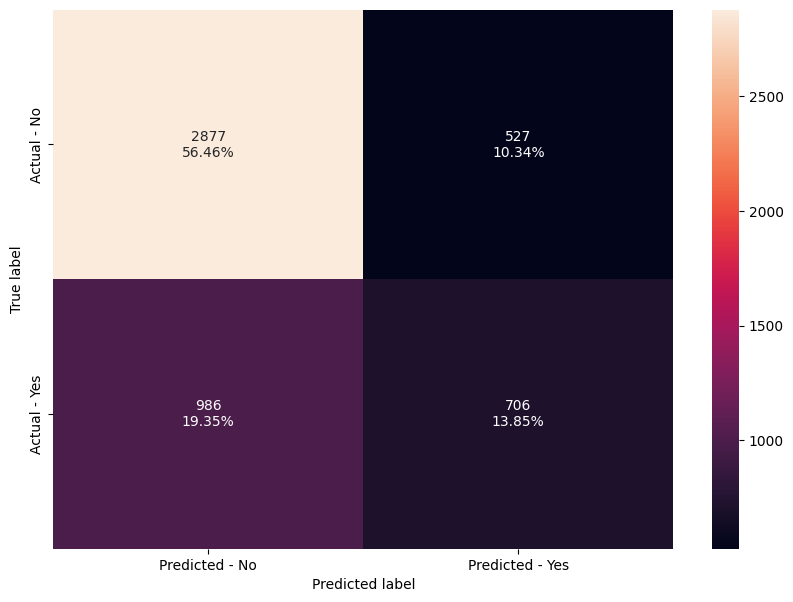

In [ ]:
#Confusion matrix
make_confusion_matrix(bagging_estimator,y_test)

- There is overfitting in the training data
- Recall is 42% and performance is poor

##Bagging classifier with hyperparameters

In [ ]:
# Choose the type of classifier.
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Only print the parameters
print("Bagging Classifier Parameters:")
print(bagging_estimator.get_params())


# Grid of parameters to choose from
## add from article
parameters = {'max_samples': [0.7,0.8,0.9],
              'max_features': [0.8,0.9,1.0],
              'n_estimators' : [30,50,70],
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
bagging_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(X_train, y_train)

Bagging Classifier Parameters:
{'bootstrap': True, 'bootstrap_features': False, 'estimator': None, 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': 1, 'verbose': 0, 'warm_start': False}


BaggingClassifier(max_samples=0.9, n_estimators=70, random_state=1)

In [ ]:
#Metrics for tuned bagging classifier
bagging_estimator_tuned_score=get_metrics_score(bagging_estimator_tuned)

Accuracy on training set :  0.9994603610675039
Accuracy on test set :  0.7207613814756672
Recall on training set :  0.9985228951255539
Recall on test set :  0.4728132387706856
Precision on training set :  0.9998520928856678
Precision on test set :  0.6010518407212622
F1-score on training set :  0.9991870519547705
F1-score on test set :  0.5292755540853457


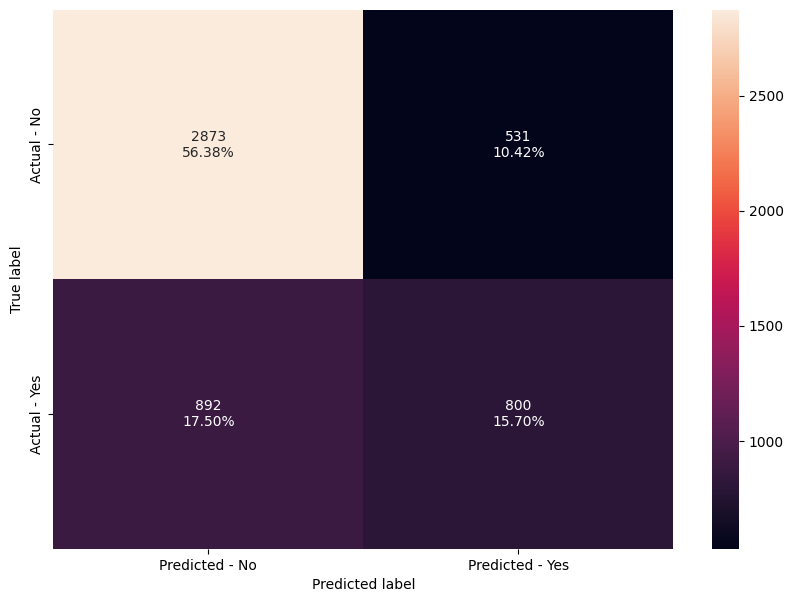

In [ ]:
#Confusion matrix
make_confusion_matrix(bagging_estimator_tuned,y_test)

- There is slight improvement in F1 score.

##Random Forest

In [ ]:
# Random forest classifier
from sklearn.ensemble import RandomForestClassifier
rf_estimator = RandomForestClassifier(random_state=1)

# Only print the parameters
print("Random Forest Classifier Parameters:")
print(rf_estimator.get_params())

#Use balanced weights
rf_estimator.class_weight='balanced'

rf_estimator.fit(X_train, y_train)

Random Forest Classifier Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 1, 'verbose': 0, 'warm_start': False}


NameError: name 'X_train' is not defined

In [ ]:
# Metric score according to function
rf_estimator_score=get_metrics_score(rf_estimator)

In [ ]:
# Confusion matrix
make_confusion_matrix(rf_estimator,y_test)

- The model is overfitting.
- Recall is not much better at 48%.

##Random forest classifier with hyperparameters

In [ ]:
# Choose the type of classifier.
rf_estimator_tuned = RandomForestClassifier(random_state=1)

# Only print the parameters
print("Random Forest Classifier Parameters:")
print(rf_estimator_tuned.get_params())

# Grid of parameters to choose from
## add from article
parameters = {"n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
              }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_tuned.fit(X_train, y_train)

In [ ]:
#Metrics for tuned random forest
rf_estimator_tuned_score=get_metrics_score(rf_estimator_tuned)

NameError: name 'get_metrics_score' is not defined

In [ ]:
#Confusion matrix
make_confusion_matrix(rf_estimator_tuned,y_test)

- The tree is not overfitting with accuracy on training set of 79%.
-Accuracy on test set is 74%.
- The recall is slightly better at 48% on the testing set.
- Precision on the test set has improved to 65%.
- The f1 score is closer to moderately balanced. Less variation between the training and testing F1 score.

In [ ]:
# importance of features in the tree building

print(pd.DataFrame(rf_estimator_tuned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

NameError: name 'pd' is not defined

In [ ]:
feature_names = X_train.columns
importances = rf_estimator_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

- Prevailing wage,Number of employees, Age og establishment, High school education level, job experience, Master's education level and unit of yearly wage are the variables of most importance.

# Boosting - Model Building and Hyperparameter Tuning

##Adaboost

In [ ]:
# Initialize the classifier
from sklearn.ensemble import AdaBoostClassifier
adaboost_estimator = AdaBoostClassifier(random_state=1)

# Only print the parameters
print("Adaboost Classifier Parameters:")
print(adaboost_estimator.get_params())
adaboost_estimator.fit(X_train, y_train)

In [ ]:
#Metrics for adaboost classifier
adaboost_estimator_score=get_metrics_score(adaboost_estimator)

In [ ]:
#Confusion matrix
make_confusion_matrix(adaboost_estimator,y_test)

##Adaboost with hyperparameters

In [ ]:
#Choose the type of classifier
adaboost_estimator_tuned = AdaBoostClassifier(random_state=1)

# Only print the parameters
print("AdaBoost Classifier Parameters:")
print(adaboost_estimator_tuned .get_params())

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01, 0.1, 0.05],
    "estimator": [  # Changed from base_estimator to estimator
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(adaboost_estimator_tuned, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
adaboost_estimator_tuned = grid_obj.best_estimator_  # Note: there was also a typo here (missing underscore)

# Fit the best algorithm to the data
adaboost_estimator_tuned.fit(X_train, y_train)

In [ ]:
#Metrics for adaboost with hyperparameter
adaboost_estimator_tuned_score=get_metrics_score(adaboost_estimator_tuned)

In [ ]:
#Confusion Matrix
make_confusion_matrix(adaboost_estimator_tuned,y_test)

NameError: name 'make_confusion_matrix' is not defined

##Gradient boost

In [ ]:
#Initialized gradient boost
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_estimator = GradientBoostingClassifier(random_state=1)

# Only print the parameters
print("Gradient Boosting Classifier Parameters:")
print(gradient_boosting_estimator.get_params())

gradient_boosting_estimator.fit(X_train, y_train)

In [ ]:
#Metrics for gradient boost classifier
gradient_boosting_estimator_score=get_metrics_score(gradient_boosting_estimator)

In [ ]:
#Confusion matrix
make_confusion_matrix(gradient_boosting_estimator,y_test)

##Gradient boost with hyperparameters

In [ ]:
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import numpy as np

# Initialize the base classifier
gradient_boosting_tuned = GradientBoostingClassifier(random_state=1)

# Only print the parameters
print("Gradient Boosting Classifier Parameters:")
print(gradient_boosting_tuned.get_params())

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50, 110, 25),
    "learning_rate": [0.01, 0.1, 0.05],
    "subsample": [0.7, 0.9],
    "max_features": [0.5, 0.7, 1.0],  # Changed 1 to 1.0 for consistency
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(gradient_boosting_tuned, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gradient_boosting_tuned = grid_obj.best_estimator_
# Fit the best algorithm to the data
gradient_boosting_tuned.fit(X_train, y_train)

In [ ]:
#Metrics for gradient boosting tuned
gradient_boosting_tuned_score=get_metrics_score(gradient_boosting_tuned)

NameError: name 'get_metrics_score' is not defined

In [ ]:
#Confusion matrix
make_confusion_matrix(gradient_boosting_tuned,y_test)

##XGBoost

In [ ]:
#Initialize classifier for XGBoost
from xgboost import XGBClassifier
xgboost_estimator = XGBClassifier(random_state=1)

# Only print the parameters
print("XGBoost Classifier Parameters:")
print(xgboost_estimator.get_params())

xgboost_estimator.fit(X_train, y_train)

XGBoost Classifier Parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 1, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


NameError: name 'X_train' is not defined

In [ ]:
#Metrics for XGBoost
xgboost_estimator_score=get_metrics_score(xgboost_estimator)

In [ ]:
#Confusion matrix
make_confusion_matrix(xgboost_estimator,y_test)


##XGBoost with hyperparameters

In [ ]:
from xgboost import XGBClassifier

 #Choose the type of classifier
xgboost_estimator_tuned = XGBClassifier(random_state=1)

# Only print the parameters
print("XGBoost Classifier Parameters:")
print(xgboost_estimator_tuned.get_params())

# Grid of parameters to choose from
parameters = {
    'n_estimators': np.arange(50,110,25),
    'scale_pos_weight': [1,2,5],
    'learning_rate': [0.01,0.1,0.05],
    'gamma': [1,3],
    'subsample': [0.7,0.9]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(xgboost_estimator_tuned, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgboost_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
xgboost_estimator_tuned.fit(X_train, y_train)

In [ ]:
#Metrics for XGBoost with hyperparameters
xgboost_estimator_tuned_score=get_metrics_score(xgboost_estimator_tuned)

In [ ]:
#Confusion matrix
make_confusion_matrix(xgboost_estimator_tuned,y_test)

- The test accuracy indicates that only 37% of the data is being predicted accurately by the model.
- A recall of 100% on test set, indicates that ALL the Visa that was actually certified, was predicted.
- Of all the visas the model predicted to approve, only about 34.5% were actually approved.
- This low precision with perfect recall confirms the model is likely predicting "approve" too frequently.
- Moderate F1 score is due to the excellent recall, despite poor precision.
- Treat outliers and review performance of the model.

##Stacking

In [ ]:
#Stacking estimator for train performance classifier
from sklearn.ensemble import StackingClassifier

In [ ]:
# Define stacking_estimator
stacking_estimator = StackingClassifier(
    estimators=[
        ('decision_tree', decision_tree_estimator_tuned),
        ('rf', rf_estimator_tuned),
        ('gradient_boosting', gradient_boosting_tuned),
        ('xgboost', xgboost_estimator_tuned)
    ],
    final_estimator=xgboost_estimator_tuned,
    cv=5
)

# Fit the model
stacking_estimator.fit(X_train, y_train)
#Evaluate
stacking_estimator_model_test_perf = model_performance_classification_sklearn(
    stacking_estimator,
    X_test,
    y_test
)
print("Testing performance \n", stacking_estimator_model_test_perf)


The stacking classifier shows signs of:

- Extreme bias toward positive predictions (very high recall but very low precision)
- Poor overall accuracy
- Worse performance than its individual components

-

##  Will tuning the hyperparameters improve the model performance?

In [ ]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

def tune_gradient_boost_efficient(X_train, y_train, random_state=1):
    """
    Efficient parameter tuning for Gradient Boosting with a focused parameter grid.

    Parameters:
    -----------
    X_train : array-like of shape (n_samples, n_features)
        Training data
    y_train : array-like of shape (n_samples,)
        Target values
    random_state : int, default=1
        Random state for reproducibility

    Returns:
    --------
    tuple
        (best_model, best_params, cv_results, grid_search)
    """

    # Initialize base model
    base_model = GradientBoostingClassifier(random_state=random_state)

    # More focused parameter grid
    param_grid = {
        "n_estimators": [50, ],  # Reduced from previous range
        "learning_rate": [0.05, 0.1],  # Removed smaller learning rates
        "max_depth": [3,],  # Reduced depth range
        "min_samples_split": [5, 10],  # Focused on middle values
        "subsample": [0.8, 0.9]  # Focused on higher subsample rates
    }

    # Create scorer - using both recall and ROC AUC
    scorers = {
        'recall': metrics.make_scorer(metrics.recall_score),
        'roc_auc': metrics.make_scorer(metrics.roc_auc_score)
    }

    # Initialize GridSearchCV with multiple scoring metrics
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=scorers,
        cv=5,
        n_jobs=-1,
        verbose=1,
        refit='roc_auc'  # Use ROC AUC to select best model
    )

    # Fit the grid search
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    return best_model, grid_search.best_params_, grid_search.cv_results_, grid_search

# Example usage:
if __name__ == "__main__":
    # Get the tuned model and results
    model, best_params, cv_results, grid_search = tune_gradient_boost_efficient(X_train, y_train)

    # Print training results
    print("\nBest parameters:", best_params)
    print("\nBest cross-validation ROC AUC score:", grid_search.best_score_)

    # Get predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Print test set metrics
    print("\nTest set performance:")
    print("ROC AUC:", metrics.roc_auc_score(y_test, y_prob))
    print("Recall:", metrics.recall_score(y_test, y_pred))
    print("Precision:", metrics.precision_score(y_test, y_pred))
    print("F1-score:", metrics.f1_score(y_test, y_pred))

    # Print detailed CV results for both metrics
    cv_results_df = pd.DataFrame(cv_results)
    print("\nDetailed cross-validation results:")
    print("Mean ROC AUC:", cv_results_df['mean_test_roc_auc'].mean())
    print("Mean Recall:", cv_results_df['mean_test_recall'].mean())
    print(cv_results_df[['param_n_estimators', 'param_learning_rate', 'param_max_depth', 'param_min_samples_split', 'param_subsample', 'mean_test_roc_auc', 'mean_test_recall']])

In [ ]:
#Confusion matrix
make_confusion_matrix(model,y_test)


- The tune gradient boost efficient model has the best performance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier

# First create and fit the model
gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    n_estimators=100,
    subsample=0.9,
    random_state=1
)

# Fit the model
gb_model.fit(X_train, y_train)

# Get feature names and importances
feature_names = X_train.columns
importances = gb_model.feature_importances_

# Sort them in ascending order for better visualization
indices = np.argsort(importances)

# Create the plot
plt.figure(figsize=(12, 12))
plt.title('Feature Importances in Gradient Boost Model', fontsize=14, pad=20)

# Create horizontal bar plot
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')

# Add feature names as y-axis labels
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

# Add labels and grid
plt.xlabel('Relative Importance', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.show()

# Print top 10 features and their importance scores
print("\nTop 10 Most Important Features:")
top_indices = np.argsort(importances)[-10:][::-1]
for idx in top_indices:
    print(f"{feature_names[idx]}: {importances[idx]:.3f}")

- Education-related features account for a large portion of the model's decisions
- Job experience is the second most important single feature
- Wage-related features (prevailing wage and unit of wage) have notable importance
- Geographic features (continent and region) have moderate influence
- Company size (no_of_employees) has relatively low importance

## Model Performance Comparison and Conclusions

In [ ]:
import pandas as pd
from tabulate import tabulate
from sklearn import metrics  # Fix: Import metrics directly from sklearn
from typing import Dict, Any

def compare_basic_metrics(
    models_dict: Dict[str, Any],
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series
) -> pd.DataFrame:
    """
    Compare multiple models using basic classification metrics.

    Parameters:
    -----------
    models_dict : Dict[str, Any]
        Dictionary of model names and their fitted model objects
    X_train : pd.DataFrame
        Training features
    X_test : pd.DataFrame
        Test features
    y_train : pd.Series
        Training labels
    y_test : pd.Series
        Test labels

    Returns:
    --------
    pd.DataFrame
        DataFrame containing comparison metrics for all models
    """
    # Store results
    results = []

    for name, model in models_dict.items():
        try:
            # Get predictions
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)

            # Calculate metrics
            metrics_dict = {
                'Model': name,
                'Train Accuracy': metrics.accuracy_score(y_train, y_pred_train),
                'Test Accuracy': metrics.accuracy_score(y_test, y_pred_test),
                'Train Recall': metrics.recall_score(y_train, y_pred_train),
                'Test Recall': metrics.recall_score(y_test, y_pred_test),
                'Train Precision': metrics.precision_score(y_train, y_pred_train),
                'Test Precision': metrics.precision_score(y_test, y_pred_test),
                'Train F1': metrics.f1_score(y_train, y_pred_train),
                'Test F1': metrics.f1_score(y_test, y_pred_test)
            }
            results.append(metrics_dict)

        except Exception as e:
            print(f"Error evaluating model {name}: {str(e)}")
            continue

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Round all numeric columns to 3 decimal places
    numeric_cols = results_df.select_dtypes(include=['float64']).columns
    results_df[numeric_cols] = results_df[numeric_cols].round(3)

    # Display results
    print("\nModel Comparison:")
    print(tabulate(results_df, headers='keys', tablefmt='pretty'))

    return results_df

# Example usage:
if __name__ == "__main__":
    # Create dictionary of your models
    models = {
        'DecisionTree': decision_tree_estimator_tuned,
        'Bagging': bagging_estimator_tuned,
        'RandomForest': rf_estimator_tuned,
        'Adaboost': adaboost_estimator_tuned,
        'GradientBoost': gradient_boosting_tuned,
        'XGBoost': xgboost_estimator_tuned,
        'TunedGradientBoost': tune_gradient_boost_efficient
    }

    # Run comparison
    results = compare_basic_metrics(models, X_train, X_test, y_train, y_test)

- Adaboost and Gradient Boost show very similar performance (Test Accuracy ≈ 0.743, Test F1 ≈ 0.56)
- Both models show good balance between precision and recall
- Neither model shows signs of overfitting (train and test metrics are close)
Best model:
- The Tuned Gradient Boost Efficient model is performing the best with this inbalanced dataset with 67% as certified and 33% as denied Visas.



In [ ]:
import numpy as np
import pandas as pd
from sklearn import metrics
from typing import Dict, Any, Tuple

def compare_advanced_metrics(
    models: Dict[str, Any],
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series
) -> Tuple[pd.DataFrame, Dict]:
    """
    Perform advanced model comparison including AUC-ROC, precision-recall curve,
    and prediction probability analysis.

    Parameters:
    -----------
    models : Dict[str, Any]
        Dictionary containing model name and fitted model object
    X_train : pd.DataFrame
        Training features
    X_test : pd.DataFrame
        Test features
    y_train : pd.Series
        Training labels
    y_test : pd.Series
        Test labels

    Returns:
    --------
    Tuple[pd.DataFrame, Dict]
        DataFrame with metrics and dictionary with detailed results
    """
    results = []
    detailed_metrics = {}

    for name, model in models.items():
        try:
            # Get probability predictions
            y_prob_train = model.predict_proba(X_train)[:, 1]
            y_prob_test = model.predict_proba(X_test)[:, 1]

            # Calculate ROC curves
            fpr_train, tpr_train, _ = metrics.roc_curve(y_train, y_prob_train)
            fpr_test, tpr_test, _ = metrics.roc_curve(y_test, y_prob_test)

            # Calculate AUC scores
            auc_train = metrics.auc(fpr_train, tpr_train)
            auc_test = metrics.auc(fpr_test, tpr_test)

            # Calculate average precision scores
            ap_train = metrics.average_precision_score(y_train, y_prob_train)
            ap_test = metrics.average_precision_score(y_test, y_prob_test)

            # Calculate log loss
            log_loss_train = metrics.log_loss(y_train, y_prob_train)
            log_loss_test = metrics.log_loss(y_test, y_prob_test)

            # Calculate brier score
            brier_train = metrics.brier_score_loss(y_train, y_prob_train)
            brier_test = metrics.brier_score_loss(y_test, y_prob_test)

            metrics_dict = {
                'Model': name,
                'Train AUC': auc_train,
                'Test AUC': auc_test,
                'Train Avg Precision': ap_train,
                'Test Avg Precision': ap_test,
                'Train Log Loss': log_loss_train,
                'Test Log Loss': log_loss_test,
                'Train Brier Score': brier_train,
                'Test Brier Score': brier_test
            }

            # Store ROC curves for plotting
            detailed_metrics[name] = {
                'fpr_train': fpr_train,
                'tpr_train': tpr_train,
                'fpr_test': fpr_test,
                'tpr_test': tpr_test,
                'auc_train': auc_train,
                'auc_test': auc_test
            }

            results.append(metrics_dict)

        except Exception as e:
            print(f"Error evaluating model {name}: {str(e)}")
            continue

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Round numeric columns
    numeric_cols = results_df.select_dtypes(include=['float64']).columns
    results_df[numeric_cols] = results_df[numeric_cols].round(3)

    # Print results
    print("\nAdvanced Metrics Comparison:")
    print(results_df.to_string(index=False))

    return results_df, detailed_metrics

# Example usage for Adaboost and Gradient Boost comparison:
if __name__ == "__main__":
    models_to_compare = {
        'Adaboost': adaboost_estimator_tuned,
        'GradientBoost': gradient_boosting_tuned
    }

    results_df, detailed_metrics = compare_advanced_metrics(
        models_to_compare,
        X_train,
        X_test,
        y_train,
        y_test
    )

NameError: name 'adaboost_estimator_tuned' is not defined

The Gradient Boost model shows advantages across all metrics, with:

- Better discrimination (higher AUC)
- Better precision
- Better calibrated probabilities (lower loss metrics)
- Similar levels of generalization (small gaps between train and test metrics)

##Improve tune gradient boost efficient model with threshold optimisation and comprehensive metrics tracking

In [ ]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
from sklearn.metrics import precision_recall_curve

def train_recall_focused_gb(X_train, X_test, y_train, y_test):
    """
    Train a Gradient Boosting model focused on maximizing recall
    while maintaining reasonable precision.
    """
    # Initialize model with class weights to focus on recall
    model = GradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=10,
        n_estimators=100,
        subsample=0.9,
        random_state=1
    )

    # Fit the model
    print("Training model...")
    model.fit(X_train, y_train)

    # Get probability predictions
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_prob_test = model.predict_proba(X_test)[:, 1]

    # Calculate precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

    # Find threshold that gives best F1 score
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
    optimal_threshold = thresholds[np.argmax(f1_scores)]

    # Try different thresholds to achieve higher recall
    test_thresholds = np.arange(0.2, 0.5, 0.05)
    best_threshold = optimal_threshold
    best_f1 = 0
    target_recall = 0.7

    for threshold in test_thresholds:
        y_pred = (y_prob_test >= threshold).astype(int)
        recall = metrics.recall_score(y_test, y_pred)
        if recall >= target_recall:
            f1 = metrics.f1_score(y_test, y_pred)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold

    optimal_threshold = best_threshold
    print(f"\nOptimal threshold for improved recall: {optimal_threshold:.3f}")

    # Get predictions with optimal threshold
    y_pred_train = (y_prob_train >= optimal_threshold).astype(int)
    y_pred_test = (y_prob_test >= optimal_threshold).astype(int)

    # Calculate metrics
    train_metrics = {
        'Accuracy': metrics.accuracy_score(y_train, y_pred_train),
        'Recall': metrics.recall_score(y_train, y_pred_train),
        'Precision': metrics.precision_score(y_train, y_pred_train),
        'F1': metrics.f1_score(y_train, y_pred_train),
        'ROC AUC': metrics.roc_auc_score(y_train, y_prob_train)
    }

    test_metrics = {
        'Accuracy': metrics.accuracy_score(y_test, y_pred_test),
        'Recall': metrics.recall_score(y_test, y_pred_test),
        'Precision': metrics.precision_score(y_test, y_pred_test),
        'F1': metrics.f1_score(y_test, y_pred_test),
        'ROC AUC': metrics.roc_auc_score(y_test, y_prob_test)
    }

    print("\nTraining Metrics:")
    for metric, value in train_metrics.items():
        print(f"{metric}: {value:.3f}")

    print("\nTesting Metrics:")
    for metric, value in test_metrics.items():
        print(f"{metric}: {value:.3f}")

    # Confusion matrix
    conf_matrix = metrics.confusion_matrix(y_test, y_pred_test)
    print("\nConfusion Matrix:")
    print(conf_matrix)

    return model, optimal_threshold, train_metrics, test_metrics, conf_matrix

# Run the recall-focused model
print("Training recall-focused Gradient Boost model...")
model, threshold, train_metrics, test_metrics, conf_matrix = train_recall_focused_gb(
    X_train, X_test, y_train, y_test
)

In [ ]:
#Show graph of  precision-recall curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

model.fit(X_train, y_train)

# Then get the probability predictions for your test set
y_prob_test = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

#Plot graph
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Threshold')
plt.ylabel;




In [ ]:
#Confusion matrix
make_confusion_matrix(model,y_test)

Model: train_recall_focused_gb:
- This model has the best recall of 72%, which is balanced with the precision of 54% to give a good F1 score of 61%.
- RUC AUC is good at 78%.

## Actionable Insights and Recommendations

The features that are the most important are:

- Education-related features account for a large portion of the model's decisions. A Bachelors id the degree most frequently associated with certification. The second qualification is a Masters degree. A high school qualification is more likely to be associated with a deneid application.

- Job experience is the second most important single feature.Certified candidates often have job experience.

- Wage-related features (prevailing wage and unit of wage) have notable importance.
- Geographic features (continent and region) have moderate influence.
- Company size (no_of_employees) has relatively low importance.

It is therefor of most importance to assess a candidate's level of education and job experience and wage related features when assessing them for a Visa. It is worthwhile aiming recruitment at graduated candidates with job experience.

Impact of location:
- Certification in Europe was the highest.There was a stepwise decrease in certification from Europe to Africa, to Asia, Oceania, North America and South America.
- The top 3 regions of certification in America is in the Midwest, South and Northeast America.
Focus on Europe, Asia and Africa for recruitment and the top regions in Amedica.

Impact of pay intervals:

- Yearly is the unit that is mostly used and approximately 70% of these candidates are certified. Hourly is the rate that is used less frequently, with 35% of the group certified.Thus focus on candidtes with monthly salaries.




